###PRIMO APPROCCIO CON IL DATASET

**Modifiche rispetto alla versione precedente**
- Correzione Fitness_Endurance: `Time_Sec == 0` non è più trattato come errore (si controlla il tempo totale).
- Pulizia dei valori impossibili estesa con regole di dominio: peso < 20 lb, componenti BIA > 1.2x peso, FFMI > 1.2x BMI, DEE > 10000, sistolica ≤ diastolica.
- Nuovi controlli: distribuzione del target, coerenza del BMI, valore ricorrente della circonferenza vita, correlazione PCIAT–sii.
- Giustificazione del drop PCIAT riscritta (target leakage).
- Correlazioni calcolate con Spearman (molte variabili sono ordinali); commenti allineati al codice.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
data_dictionary = pd.read_csv('data_dictionary.csv')

In [3]:
df = pd.read_csv('cmi_internet.csv')

In [4]:
df.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,2,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,4,Spring,18,1,Summer,65.0,NaN,17.937682,NaN,77.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,1.0,0.0


In [5]:
df.describe()

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,...,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii
count,8460.000000,8460.000000,8460.000000,7034.000000,7591.000000,7595.000000,7641.000000,5624.000000,7528.000000,7539.000000,...,2714.000000,2714.000000,2714.000000,2714.000000,2714.000000,2714.000000,4903.000000,4903.000000,7849.000000,8460.000000
mean,4229.500000,10.240189,0.402364,67.021041,19.532651,57.189069,84.428737,26.959113,68.937566,81.894150,...,1.447310,1.621592,1.611275,1.157701,0.940310,27.855195,41.410667,58.072813,0.981144,0.443853
std,2442.335972,3.574680,0.490404,35.284140,4.683925,7.374577,40.218441,3.821844,11.162469,11.380533,...,1.491957,1.443668,1.525420,1.340968,1.181054,20.318784,9.464932,12.563287,1.046645,0.731014
min,0.000000,5.000000,0.000000,25.000000,0.000000,33.000000,0.000000,18.000000,0.000000,27.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,38.000000,0.000000,0.000000
25%,2114.750000,7.000000,0.000000,60.500000,16.541742,51.500000,55.200000,25.000000,62.500000,75.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,35.000000,50.000000,0.000000,0.000000
50%,4229.500000,10.000000,0.000000,65.000000,17.937682,55.700000,75.000000,26.000000,68.000000,81.500000,...,1.000000,1.000000,1.000000,1.000000,1.000000,26.000000,39.500000,55.000000,1.000000,0.000000
75%,6344.250000,12.000000,1.000000,70.500000,21.469546,63.000000,107.000000,28.250000,72.500000,87.000000,...,2.000000,3.000000,2.000000,2.000000,1.000000,41.000000,45.000000,62.500000,2.000000,1.000000
max,8459.000000,22.000000,1.000000,999.000000,59.132048,78.500000,315.000000,50.000000,179.000000,138.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,93.000000,96.000000,100.000000,3.000000,3.000000


In [6]:
df.dtypes

id                                          int64
Basic_Demos-Enroll_Season                  object
Basic_Demos-Age                             int64
Basic_Demos-Sex                             int64
CGAS-Season                                object
                                           ...   
SDS-SDS_Total_Raw                         float64
SDS-SDS_Total_T                           float64
PreInt_EduHx-Season                        object
PreInt_EduHx-computerinternet_hoursday    float64
sii                                       float64
Length: 82, dtype: object

In [7]:
#controllo missing values in percentuale
df.isnull().sum() / len(df) * 100

id                                         0.000000
Basic_Demos-Enroll_Season                  0.000000
Basic_Demos-Age                            0.000000
Basic_Demos-Sex                            0.000000
CGAS-Season                               15.390071
                                            ...    
SDS-SDS_Total_Raw                         42.044917
SDS-SDS_Total_T                           42.044917
PreInt_EduHx-Season                        4.598109
PreInt_EduHx-computerinternet_hoursday     7.222222
sii                                        0.000000
Length: 82, dtype: float64

In [8]:
#droppo id e le colonne che iniziano con Basic_Demos e chiamo il nuovo dataset df_missing
df_missing = df.drop(columns=['id'] + [col for col in df.columns if col.startswith('Basic_Demos')])

In [9]:
df_missing

,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,Winter,51.0,Fall,16.877316,46.00,50.8,26.00,NaN,NaN,114.0,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,NaN,NaN,Fall,14.035590,48.00,46.0,22.00,75.0,70.0,122.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,Fall,71.0,Fall,16.648696,56.50,75.6,NaN,65.0,94.0,117.0,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,Fall,71.0,Summer,18.292347,56.00,81.6,26.00,60.0,97.0,117.0,...,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,Summer,65.0,NaN,17.937682,NaN,77.0,26.00,68.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,Spring,NaN,Fall,16.130585,46.07,49.0,22.25,58.5,82.5,NaN,...,NaN,NaN,NaN,NaN,Summer,38.5,55.0,Spring,0.0,0.0
8456,Spring,69.5,Winter,NaN,56.13,47.8,28.50,66.0,80.5,107.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Winter,0.0,1.0
8457,Winter,70.0,Winter,40.937571,49.56,47.2,NaN,63.5,83.5,119.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,2.0,0.0
8458,NaN,55.5,Spring,NaN,63.79,99.5,31.10,NaN,87.5,108.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,1.0,2.0


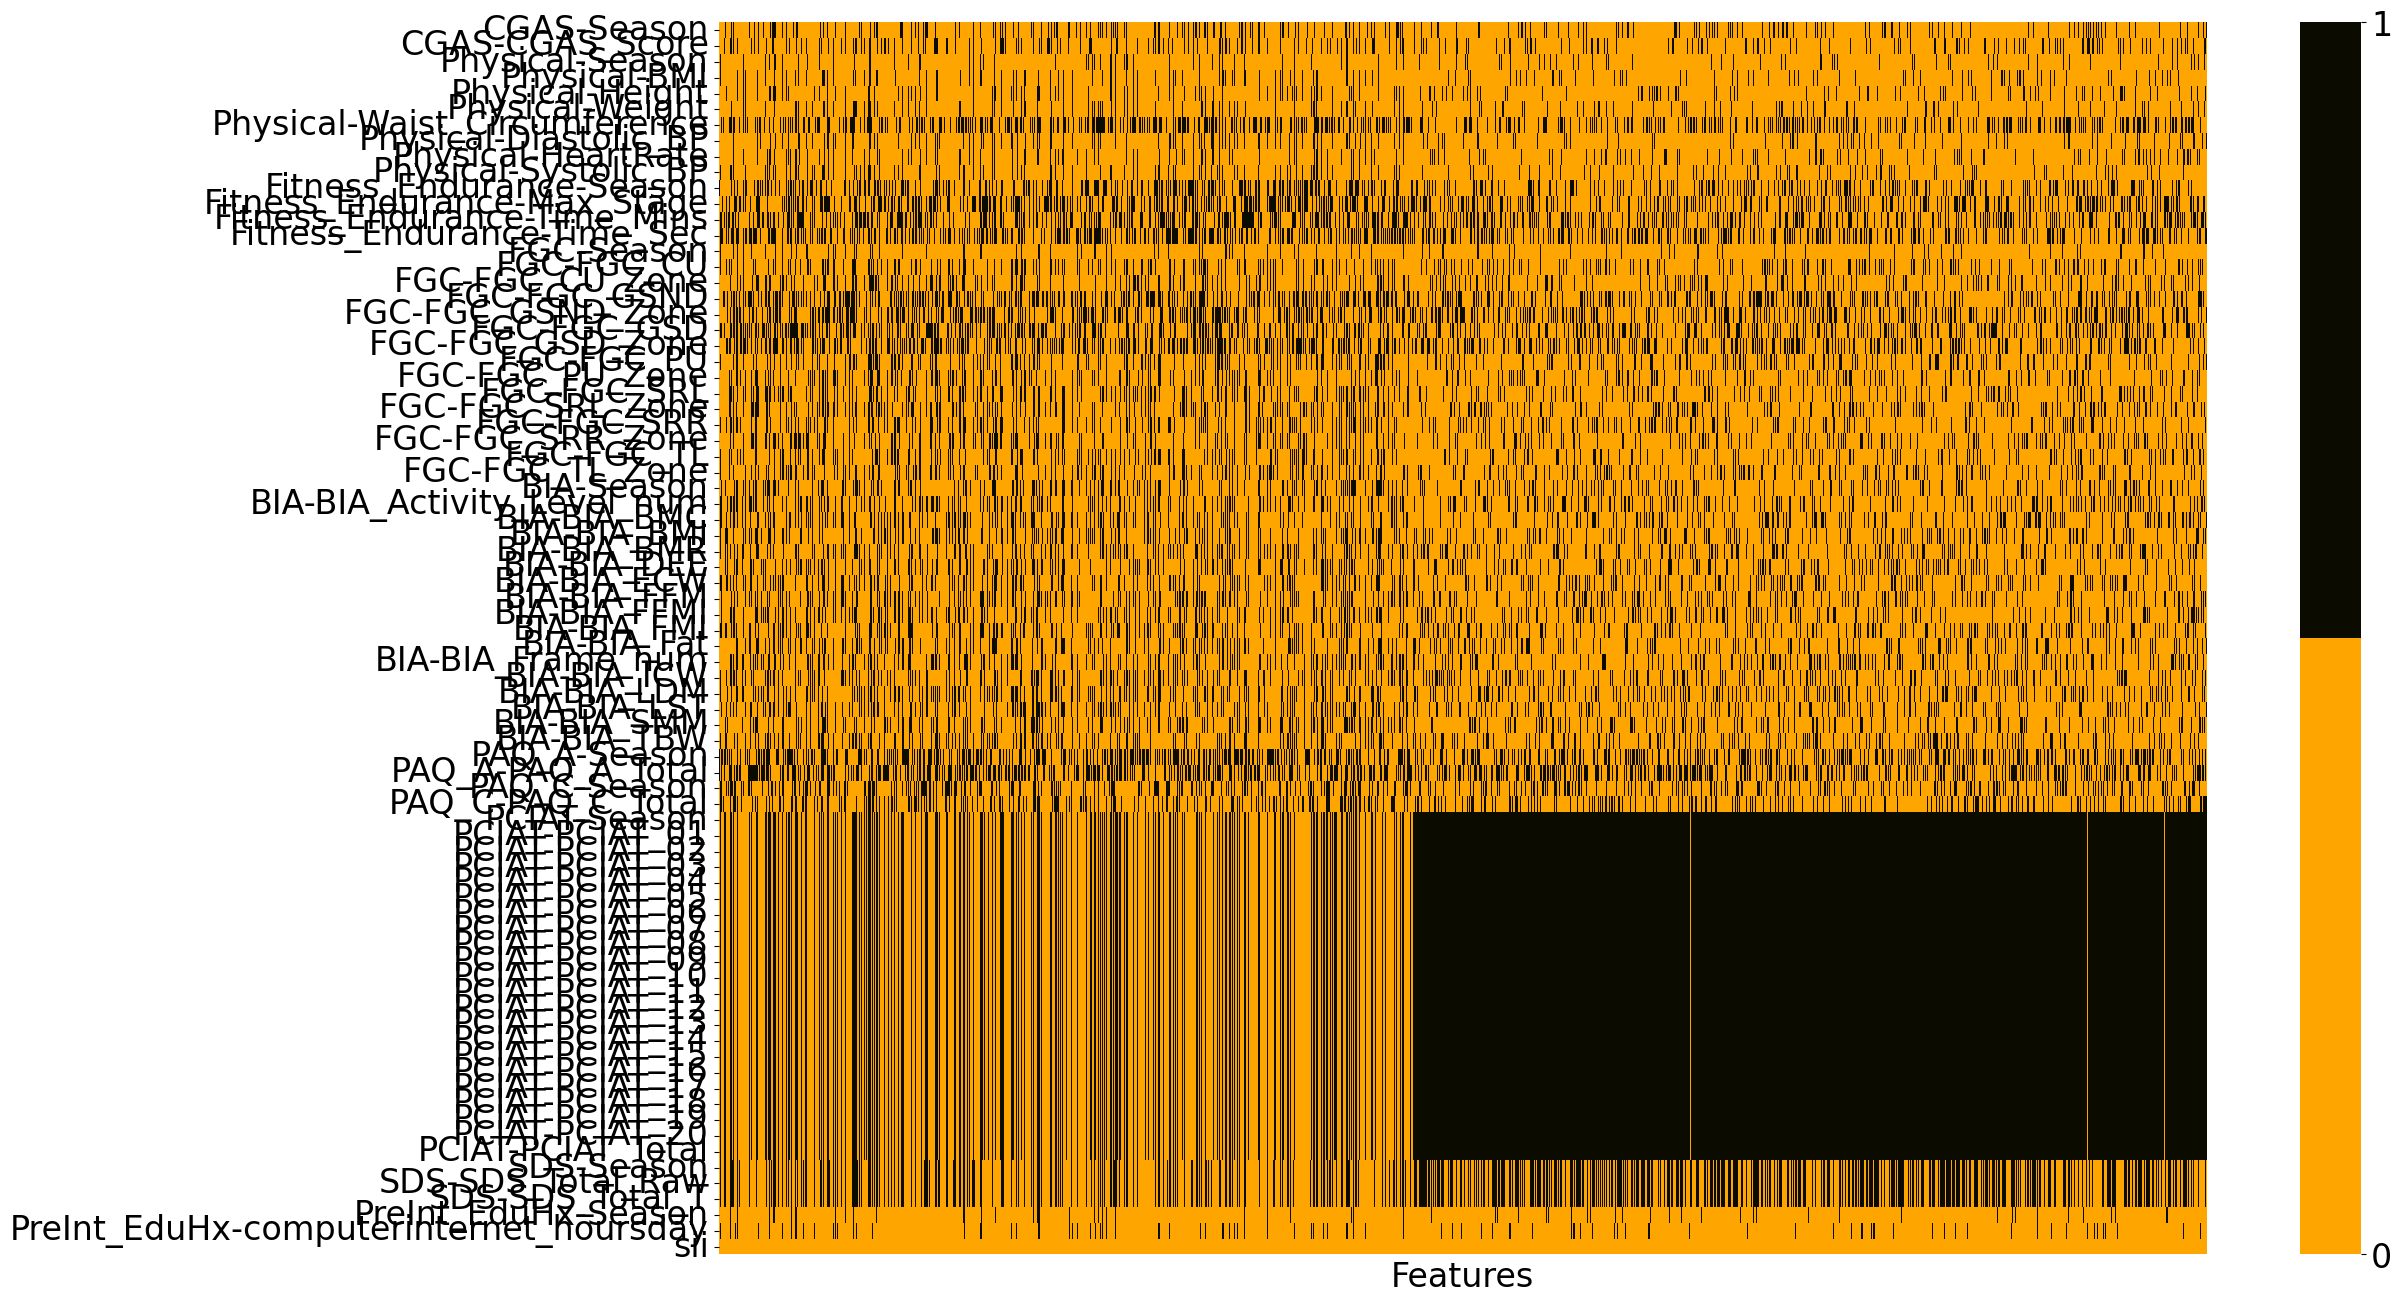

In [10]:
#rappesento graficamente la percentuale di missing values usando
import missingno as msno

# Crea una mappa dei colori personalizzata con un colore più arancione e nero
from matplotlib.colors import LinearSegmentedColormap

# Definisci i colori
colors = ["#FFA500", "#0c0b00"]  # Nero e un arancione più arancione

# Crea la mappa dei colori
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=2)

# Personalizza la dimensione della figura per la leggibilità
plt.figure(figsize=(24, 16))

# Trasponi il DataFrame per invertire gli assi
sns.heatmap(df_missing.isnull().T, cbar=True, cmap=cmap, cbar_kws={'ticks': [0, 1]})

plt.gca().collections[0].colorbar.ax.tick_params(labelsize=24)  # Regola il font delle etichette dei tick

# Aggiungi titolo e etichette per chiarezza
plt.xlabel("Features", fontsize=24)  # Features sull'asse x ora
# Rimuovi i numeri sull'asse delle x
plt.xticks([])
plt.yticks(fontsize=24)

plt.show()

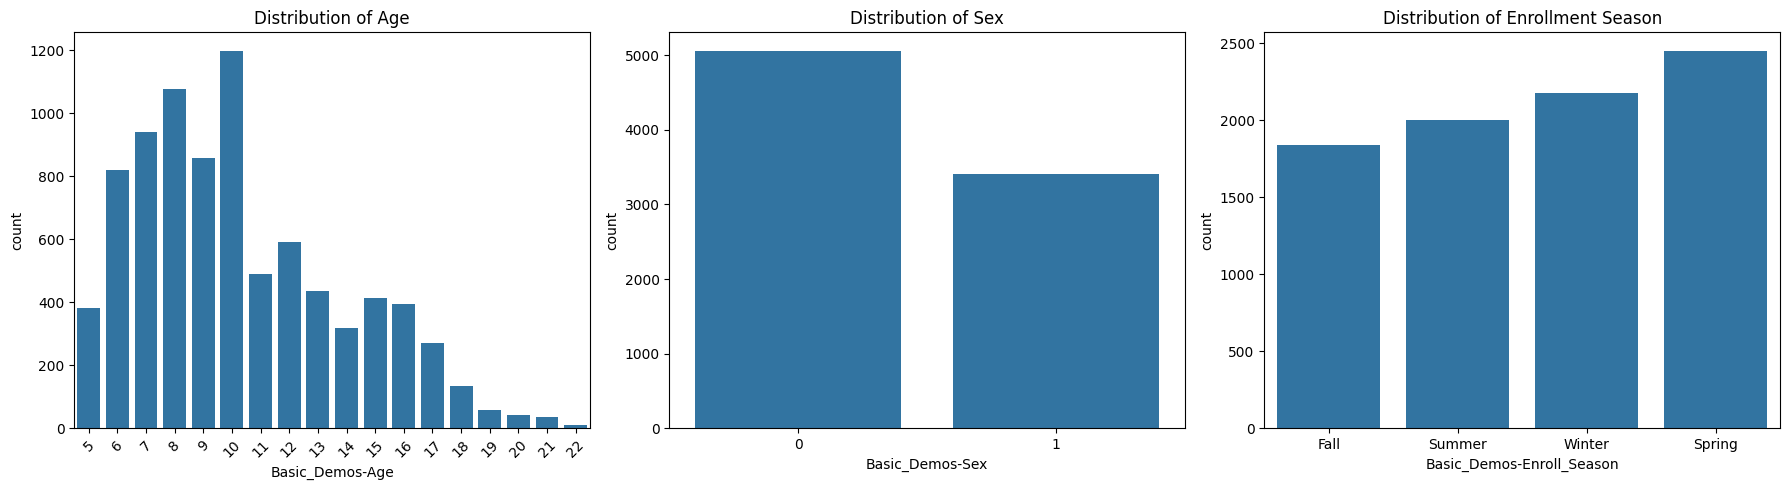

In [11]:

# Creiamo una figura con 1 riga e 3 colonne
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Grafico 1: Age
sns.countplot(data=df, x='Basic_Demos-Age', ax=axes[0])
axes[0].set_title('Distribution of Age')
axes[0].tick_params(axis='x', rotation=45) # Ruota le etichette se sono troppe

# Grafico 2: Sex
sns.countplot(data=df, x='Basic_Demos-Sex', ax=axes[1])
axes[1].set_title('Distribution of Sex')

# Grafico 3: Enrollment Season
sns.countplot(data=df, x='Basic_Demos-Enroll_Season', ax=axes[2])
axes[2].set_title('Distribution of Enrollment Season')

# Ottimizza lo spazio tra i grafici
plt.tight_layout()
plt.show()

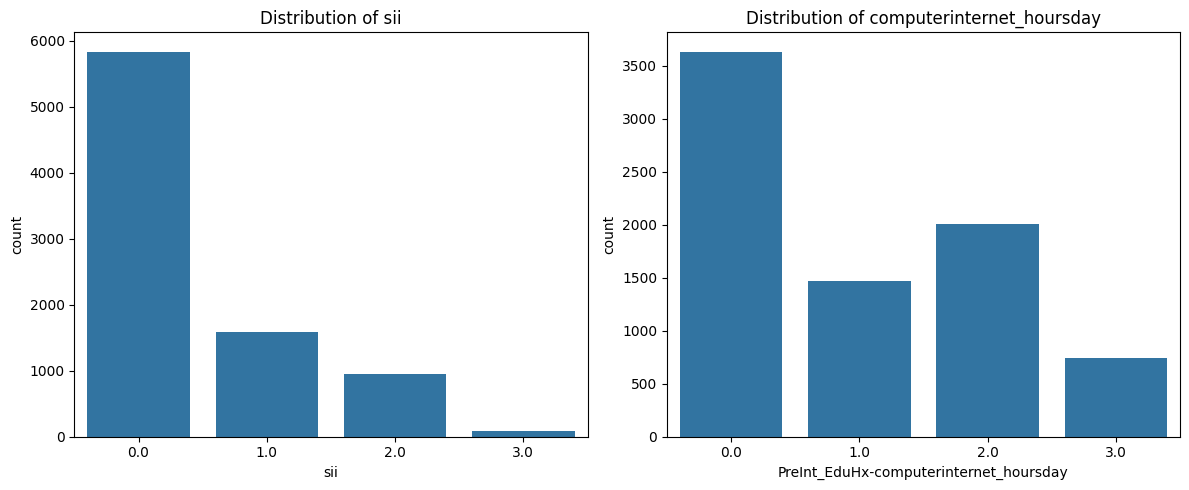

sii
0.0    68.9
1.0    18.8
2.0    11.3
3.0     1.0
Name: proportion, dtype: float64


In [12]:
#distribuzione dei target: sii e ore al computer
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='sii', ax=axes[0])
axes[0].set_title('Distribution of sii')
sns.countplot(data=df, x='PreInt_EduHx-computerinternet_hoursday', ax=axes[1])
axes[1].set_title('Distribution of computerinternet_hoursday')
plt.tight_layout()
plt.show()
print((df['sii'].value_counts(normalize=True).sort_index() * 100).round(1))

Il target `sii` è fortemente sbilanciato: la classe 3 rappresenta circa l'1% del dataset (88 righe).

### age distribution

Text(0.5, 1.0, 'Distribution of Age')

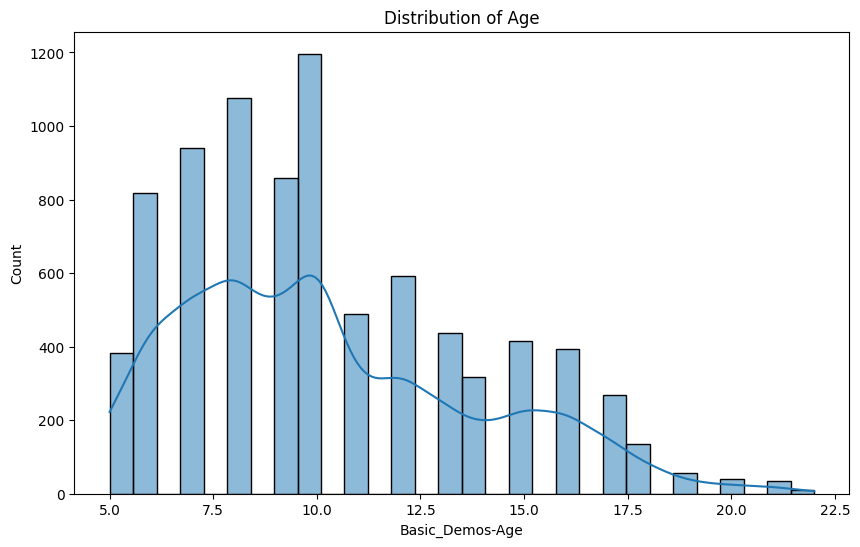

In [13]:
# distribuzione dell'età
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Basic_Demos-Age', bins=30, kde=True)
plt.title('Distribution of Age')

In [14]:
df['Basic_Demos-Age'].describe()

count    8460.000000
mean       10.240189
std         3.574680
min         5.000000
25%         7.000000
50%        10.000000
75%        12.000000
max        22.000000
Name: Basic_Demos-Age, dtype: float64

### CGAS Score

In [15]:
#il CGAS_Score dovrebbe andare da 1 a 100, controllo se ci sono valori minori o maggiori
print("Numero di valori superiori a 100:", (df['CGAS-CGAS_Score'] > 100).sum())
print("Numero di valori inferiori a 1:", (df['CGAS-CGAS_Score'] < 1).sum())


Numero di valori superiori a 100: 16
Numero di valori inferiori a 1: 0


Il CGAS_Score, che dovrebbe andare da 1 a 100, presenta valori fuori da questa scala

#### CGAS Score distribution

Text(0.5, 1.0, 'Distribution of CGAS Season')

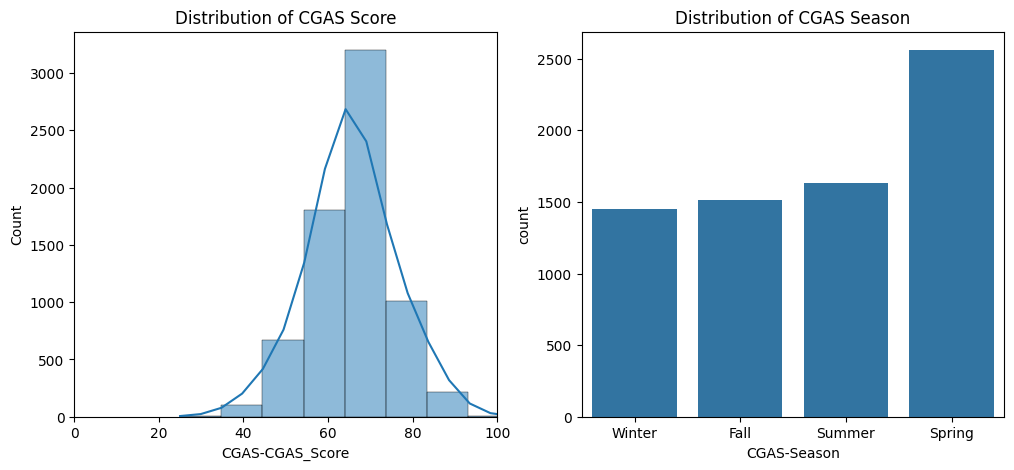

In [16]:
#Controllo la distribuzione delle variabili CGAS
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#istogramma valori tra 1 e 100
sns.histplot(df['CGAS-CGAS_Score'], bins=100, kde=True, ax=axes[0])
axes[0].set_title('Distribution of CGAS Score')
axes[0].set_xlim(0, 100) # Limiti dell'asse x da 0 a 100

sns.countplot(data=df, x='CGAS-Season', ax=axes[1])
axes[1].set_title('Distribution of CGAS Season')

### Physical variable distribution

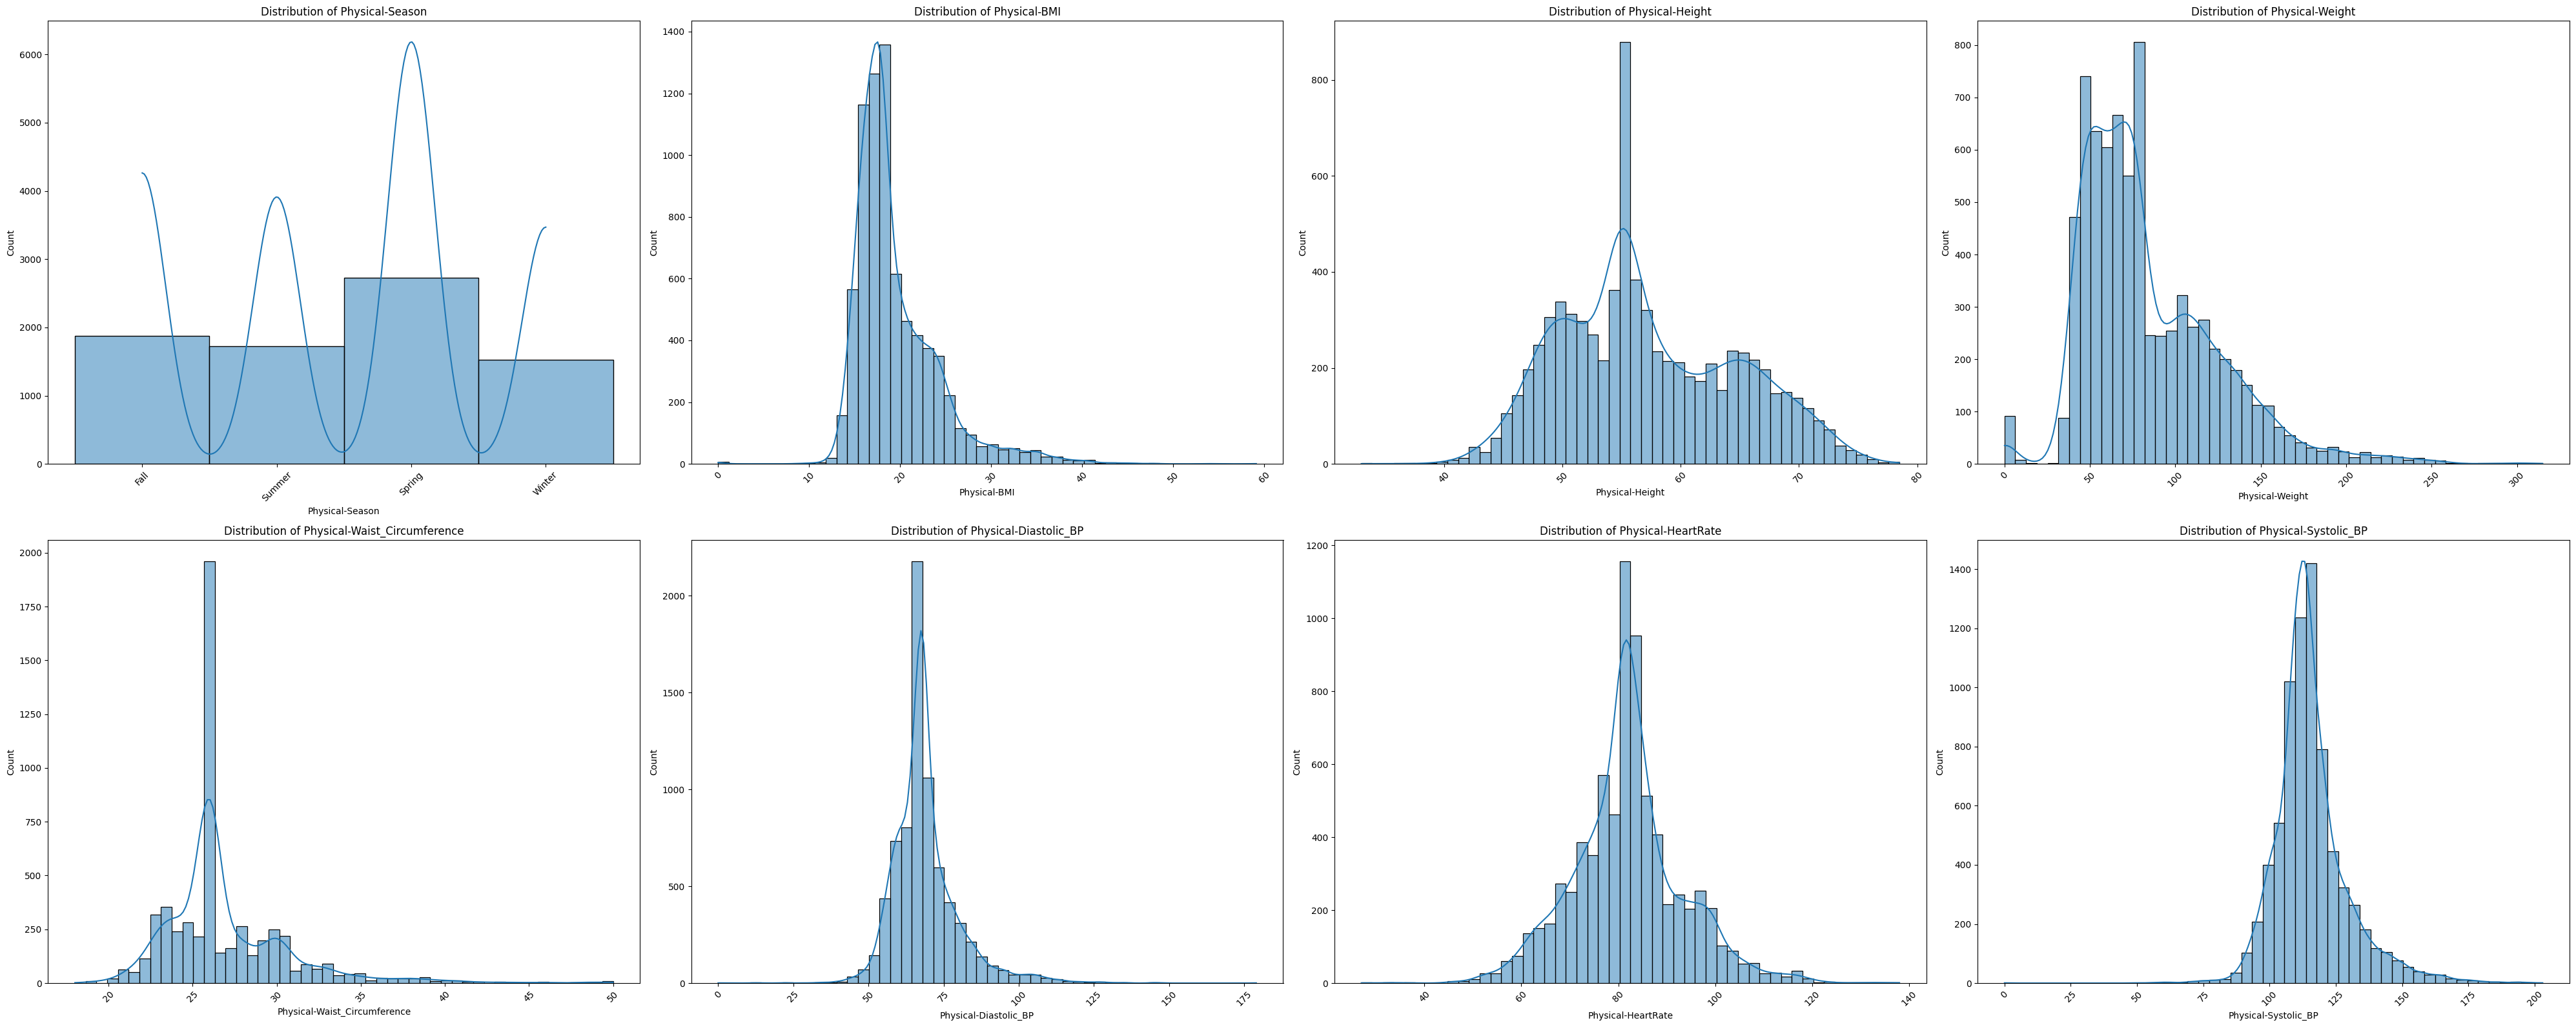

In [17]:
#controllo el distribuzioni delle variabili fisiche
fig, axes = plt.subplots(2, 4, figsize=(40, 16))
#isolo le variabili fisiche
physical_vars = [col for col in df.columns if 'Physical' in col]
for i, var in enumerate(physical_vars):
    sns.histplot(df[var], bins=50, kde=True, ax=axes[i//4, i%4])
    axes[i//4, i%4].set_title(f'Distribution of {var}')
    axes[i//4, i%4].tick_params(axis='x', rotation=45) # Ruota le etichette se sono troppe
plt.tight_layout()
plt.show()


#### Check sui vari valori
- BMI tra 10 e 50
- altezza superiore a 75 e inferiore a 35
- peso tra 35 e 250 lbs

In [18]:
#controllo valori anomali del BMI, minore di 10 o maggiore di 50
print("Numero di valori di BMI superiori a 50:", (df['Physical-BMI'] > 50).sum())
print("Numero di valori di BMI inferiori a 10:", (df['Physical-BMI'] < 10).sum())
print("Numero di valori di BMI uguali a 0:", (df['Physical-BMI'] == 0).sum())


Numero di valori di BMI superiori a 50: 2
Numero di valori di BMI inferiori a 10: 10
Numero di valori di BMI uguali a 0: 7


In [19]:
#controllo valori anomali dell'altezza, minore di 35 e maggiore di 75
print("Numero di valori di Height superiori a 75:", (df['Physical-Height'] > 75).sum())
print("Numero di valori di Height inferiori a 35:", (df['Physical-Height'] < 35).sum())
print("Numero di valori di Height uguali a 0:", (df['Physical-Height'] == 0).sum())

Numero di valori di Height superiori a 75: 34
Numero di valori di Height inferiori a 35: 1
Numero di valori di Height uguali a 0: 0


In [20]:
#controlllo valori anomali del peso in lbs, minore di 35 e maggiore di 250
print("Numero di valori di Weight superiori a 250:", (df['Physical-Weight'] > 250).sum())
print("Numero di valori di Weight inferiori a 35:", (df['Physical-Weight'] < 35).sum())
print("Numero di valori di Weight uguali a 0:", (df['Physical-Weight'] == 0).sum()) 

Numero di valori di Weight superiori a 250: 18
Numero di valori di Weight inferiori a 35: 134
Numero di valori di Weight uguali a 0: 81


In [21]:
#controllo coerenza del BMI: Physical-BMI dovrebbe essere uguale a 703 * peso(lb) / altezza(in)^2
bmi_calc = 703 * df['Physical-Weight'] / df['Physical-Height']**2
validi = (df['Physical-Weight'] > 0) & (df['Physical-Height'] > 0) & (df['Physical-BMI'] > 0)
rapporto = (bmi_calc / df['Physical-BMI'])[validi]
print(f"BMI coerente con peso e altezza (entro il 2%): {(abs(rapporto - 1) < 0.02).mean()*100:.1f}% delle righe")
print("Righe con BMI presente ma peso uguale a 0:", ((df['Physical-BMI'] > 0) & (df['Physical-Weight'] == 0)).sum())
#-> il BMI originale non è affidabile: viene ricalcolato da peso e altezza nel data preparation

BMI coerente con peso e altezza (entro il 2%): 49.9% delle righe
Righe con BMI presente ma peso uguale a 0: 48


In [22]:
print(df['Physical-Waist_Circumference'].mode())
(df['Physical-Waist_Circumference'] == 26.0).sum()

0    26.0
Name: Physical-Waist_Circumference, dtype: float64


np.int64(1633)

Il valore 26.0 compare 1633 volte, circa il 29% dei valori presenti, mentre il secondo valore più frequente compare 182 volte: è probabilmente un valore di riempimento di default e non una misura reale. Non lo modifichiamo, ma va tenuto presente nell'interpretazione di questa variabile.

In [23]:
#controllo valori anomali della circonferenza vita, minore di 20 e maggiore di 45
print("Numero di valori di Waist_Circumference superiori a 45:", (df['Physical-Waist_Circumference'] > 45).sum())
print("Numero di valori di Waist_Circumference inferiori a 20:", (df['Physical-Waist_Circumference'] < 20).sum())
print("Numero di valori di Waist_Circumference uguali a 0:", (df['Physical-Waist_Circumference'] == 0).sum())

Numero di valori di Waist_Circumference superiori a 45: 25
Numero di valori di Waist_Circumference inferiori a 20: 12
Numero di valori di Waist_Circumference uguali a 0: 0


In [24]:
#controllo valori anomali della pressione sanguigna diastolica, minore di 50 e maggiore di 100
print("Numero di valori di Diastolic_BP inferiori a 50:", (df['Physical-Diastolic_BP'] < 50).sum())
print("Numero di valori di Diastolic_BP superiori a 100:", (df['Physical-Diastolic_BP'] > 100).sum())
print("Numero di valori di Diastolic_BP uguali a 0:", (df['Physical-Diastolic_BP'] == 0).sum())

Numero di valori di Diastolic_BP inferiori a 50: 101
Numero di valori di Diastolic_BP superiori a 100: 173
Numero di valori di Diastolic_BP uguali a 0: 1


In [25]:
#controllo valori anomali della pressione sanguigna sistolica, minore di 90 e maggiore di 150
print("Numero di valori di Systolic_BP inferiori a 90:", (df['Physical-Systolic_BP'] < 90).sum())
print("Numero di valori di Systolic_BP superiori a 150:", (df['Physical-Systolic_BP'] > 150).sum())
print("Numero di valori di Systolic_BP uguali a 0:", (df['Physical-Systolic_BP'] == 0).sum())


Numero di valori di Systolic_BP inferiori a 90: 86
Numero di valori di Systolic_BP superiori a 150: 205
Numero di valori di Systolic_BP uguali a 0: 1


In [26]:
#controllo coerenza sistolica/diastolica: la sistolica deve essere sempre maggiore della diastolica
print("Righe con Systolic <= Diastolic:", (df['Physical-Systolic_BP'] <= df['Physical-Diastolic_BP']).sum())

Righe con Systolic <= Diastolic: 13


In [27]:
#controllo valori anomali dell'heartRate, minore di 40 e maggiore di 120
print("Numero di valori di Heart_Rate inferiori a 40:", (df['Physical-HeartRate'] < 40).sum())
print("Numero di valori di Heart_Rate superiori a 120:", (df['Physical-HeartRate'] > 120).sum())
print("Numero di valori di Heart_Rate uguali a 0:", (df['Physical-HeartRate'] == 0).sum())

Numero di valori di Heart_Rate inferiori a 40: 4
Numero di valori di Heart_Rate superiori a 120: 14
Numero di valori di Heart_Rate uguali a 0: 0


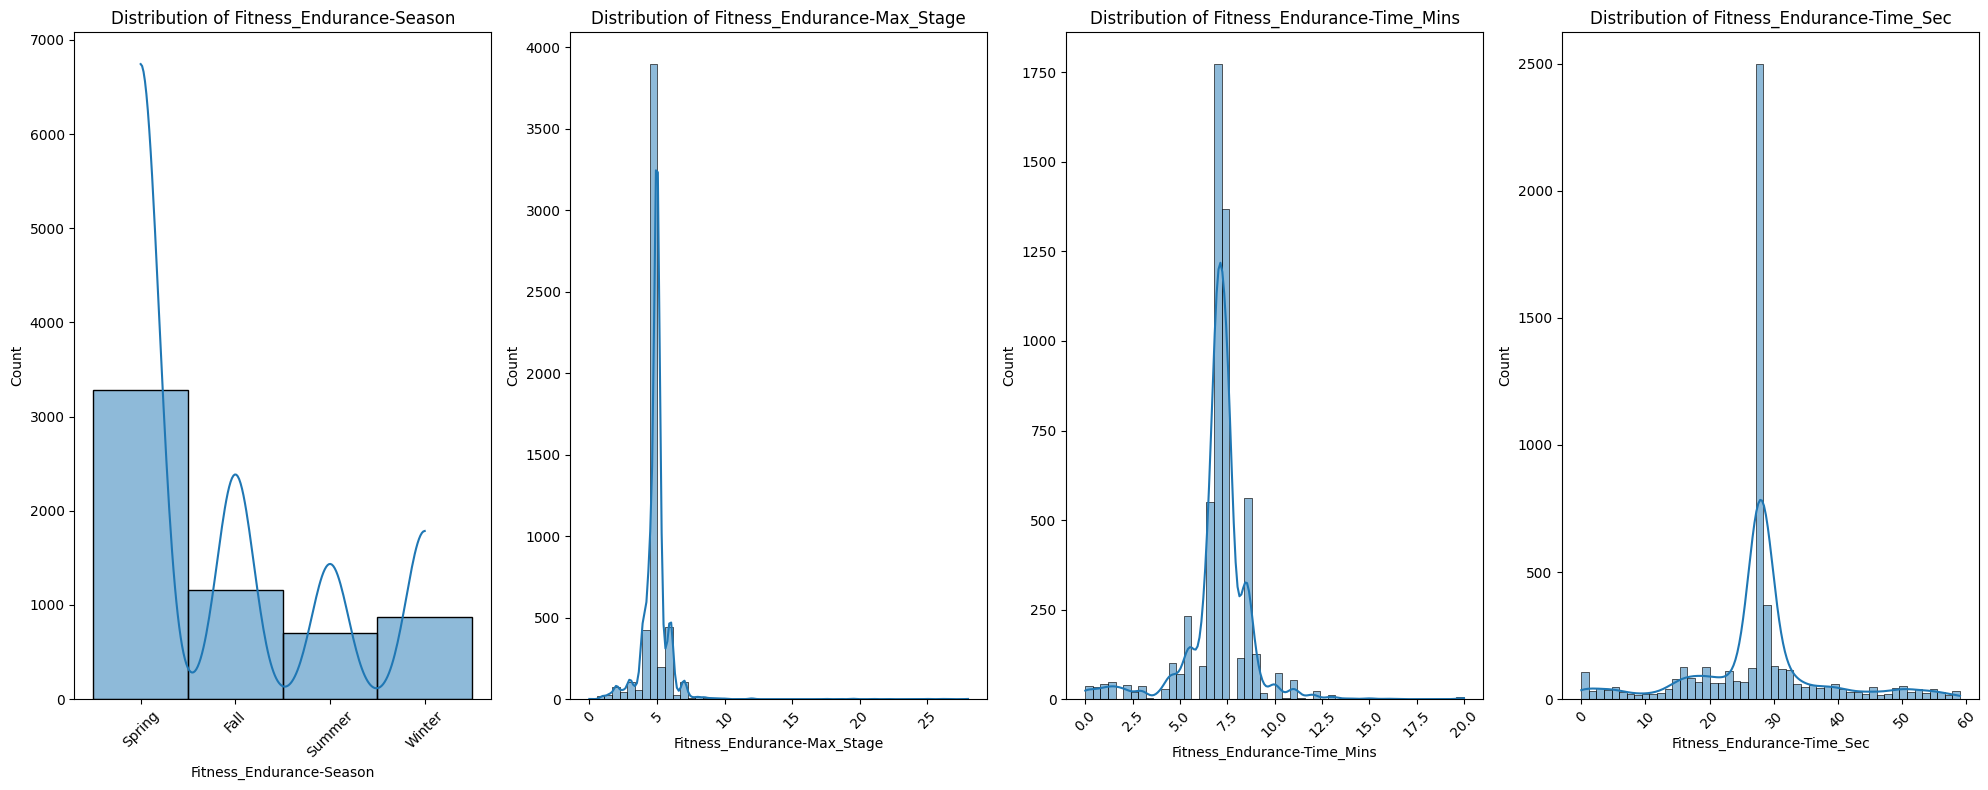

In [28]:
#Controllo distribuzioni delle variabili della categoria FitnessGram Vitals and Treadmill
#Isolo prima le variabili
fitnessgram_vars = [col for col in df.columns if 'Fitness_Endurance' in col]
fig, axes = plt.subplots(1, 4, figsize=(20, 8))
for i, var in enumerate(fitnessgram_vars):
    sns.histplot(df[var], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {var}')
    axes[i].tick_params(axis='x', rotation=45) 
plt.tight_layout()
plt.show()


In [29]:
#funzione per cercare gli 0
def conta_zero(df, column):
    return (df[column] == 0).sum()

In [30]:
conta_zero(df, 'Fitness_Endurance-Time_Mins')

np.int64(37)

In [31]:
conta_zero(df, 'Fitness_Endurance-Time_Sec')

np.int64(76)

In [32]:
conta_zero(df, 'Fitness_Endurance-Max_Stage')

np.int64(1)

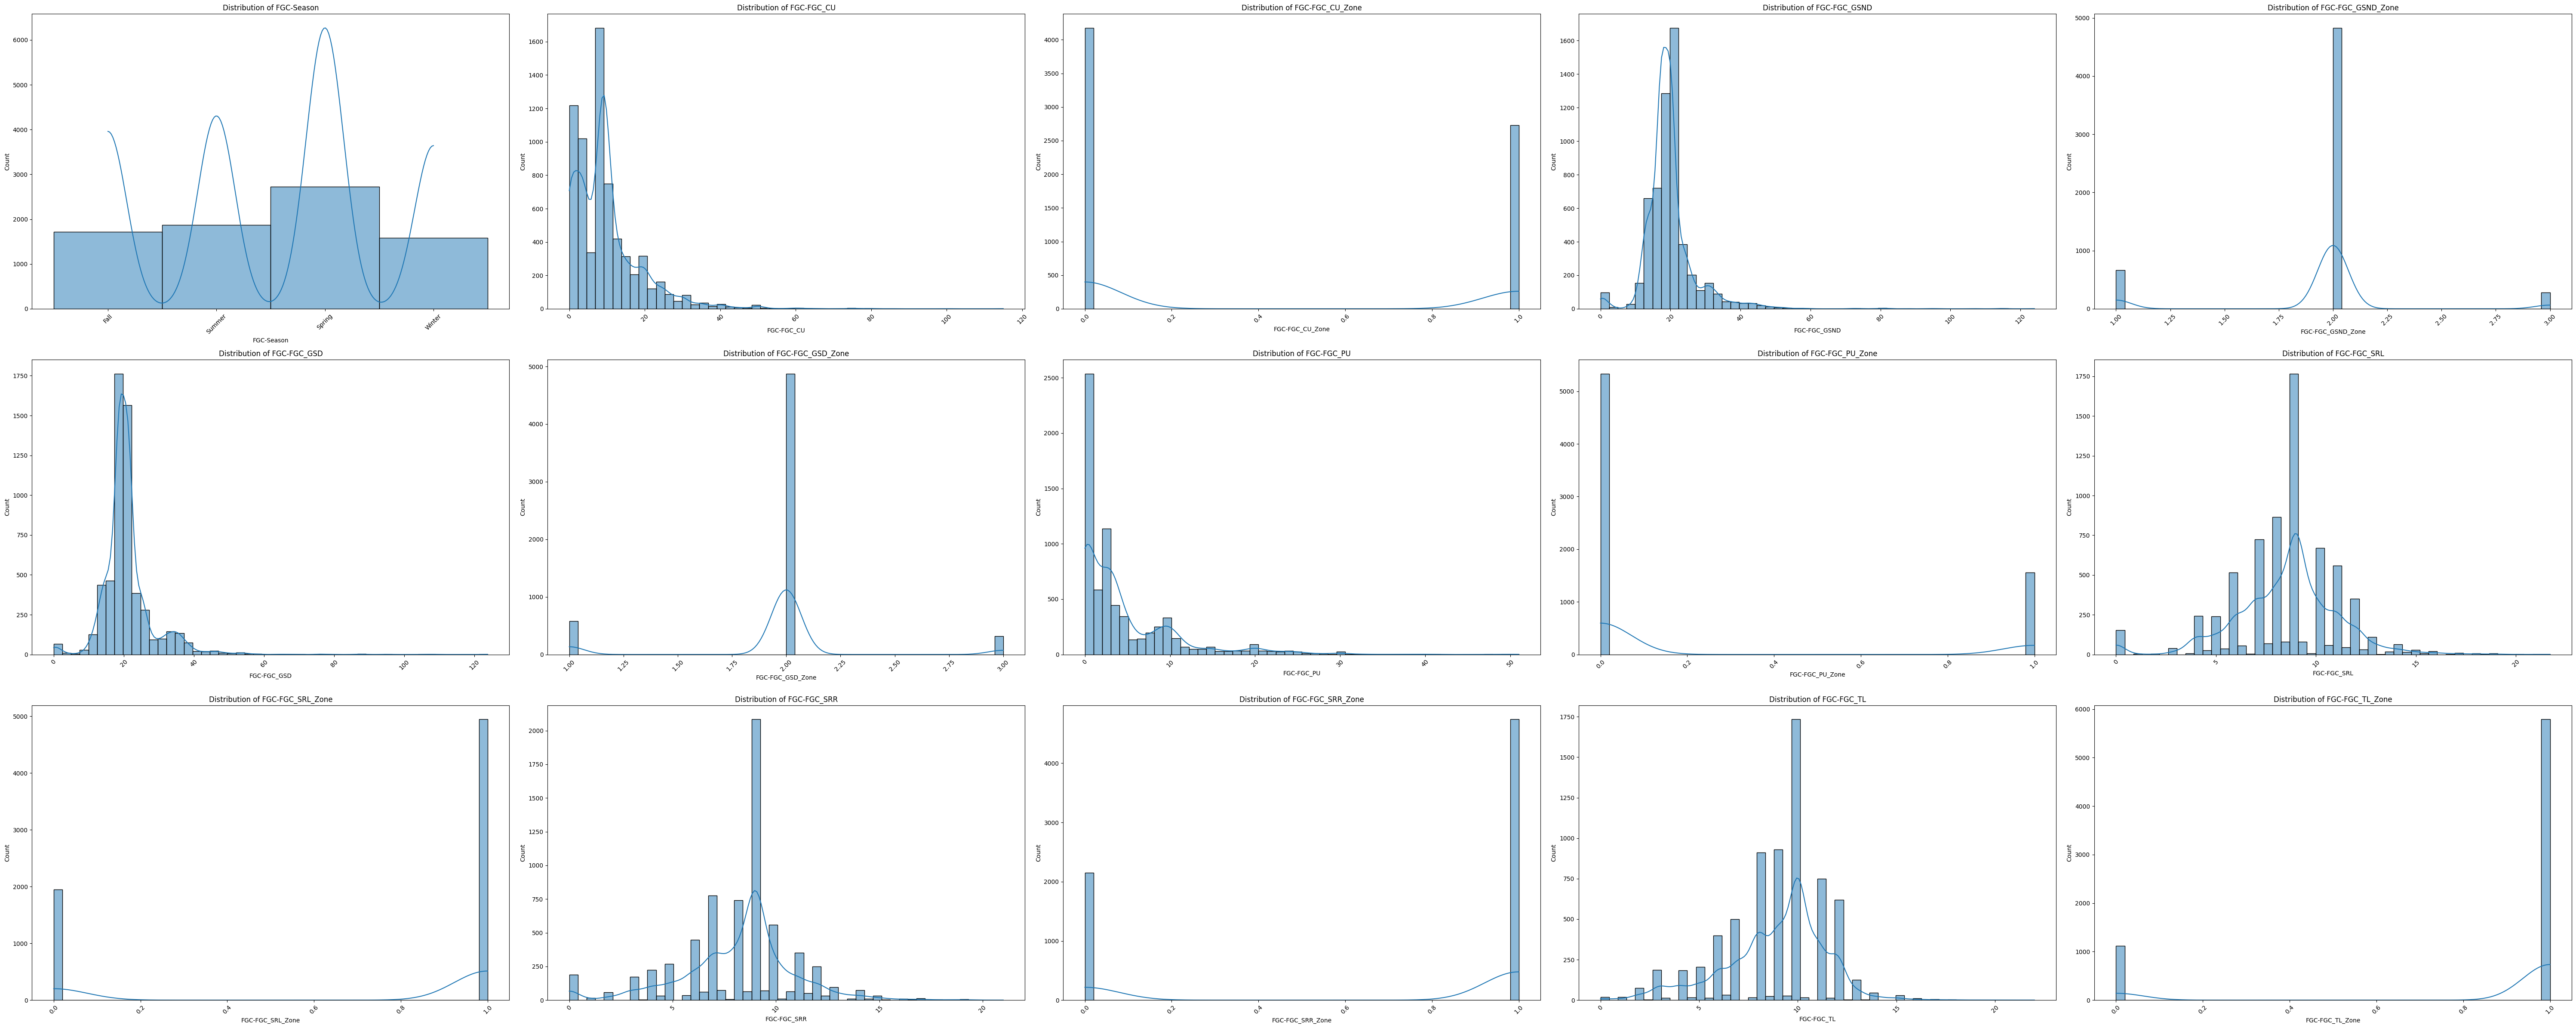

In [33]:
#controllo le distribuzioni delle variabili FitnessGram Child
childvars = [col for col in df.columns if 'FGC' in col]
fig, axes = plt.subplots(3, 5, figsize=(60, 24))
for i, var in enumerate(childvars):
    sns.histplot(df[var], bins=50, kde=True, ax=axes[i//5, i%5])
    axes[i//5, i%5].set_title(f'Distribution of {var}')
    axes[i//5, i%5].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [34]:
#controllo quanti valori uguali a 0 ha ognuna delle colonne in childvars
for var in childvars:
    print(f"Numero di valori uguali a 0 in {var}: {conta_zero(df, var)}")

Numero di valori uguali a 0 in FGC-Season: 0
Numero di valori uguali a 0 in FGC-FGC_CU: 808
Numero di valori uguali a 0 in FGC-FGC_CU_Zone: 4175
Numero di valori uguali a 0 in FGC-FGC_GSND: 42
Numero di valori uguali a 0 in FGC-FGC_GSND_Zone: 0
Numero di valori uguali a 0 in FGC-FGC_GSD: 34
Numero di valori uguali a 0 in FGC-FGC_GSD_Zone: 0
Numero di valori uguali a 0 in FGC-FGC_PU: 2001
Numero di valori uguali a 0 in FGC-FGC_PU_Zone: 5336
Numero di valori uguali a 0 in FGC-FGC_SRL: 154
Numero di valori uguali a 0 in FGC-FGC_SRL_Zone: 1946
Numero di valori uguali a 0 in FGC-FGC_SRR: 188
Numero di valori uguali a 0 in FGC-FGC_SRR_Zone: 2152
Numero di valori uguali a 0 in FGC-FGC_TL: 19
Numero di valori uguali a 0 in FGC-FGC_TL_Zone: 1118


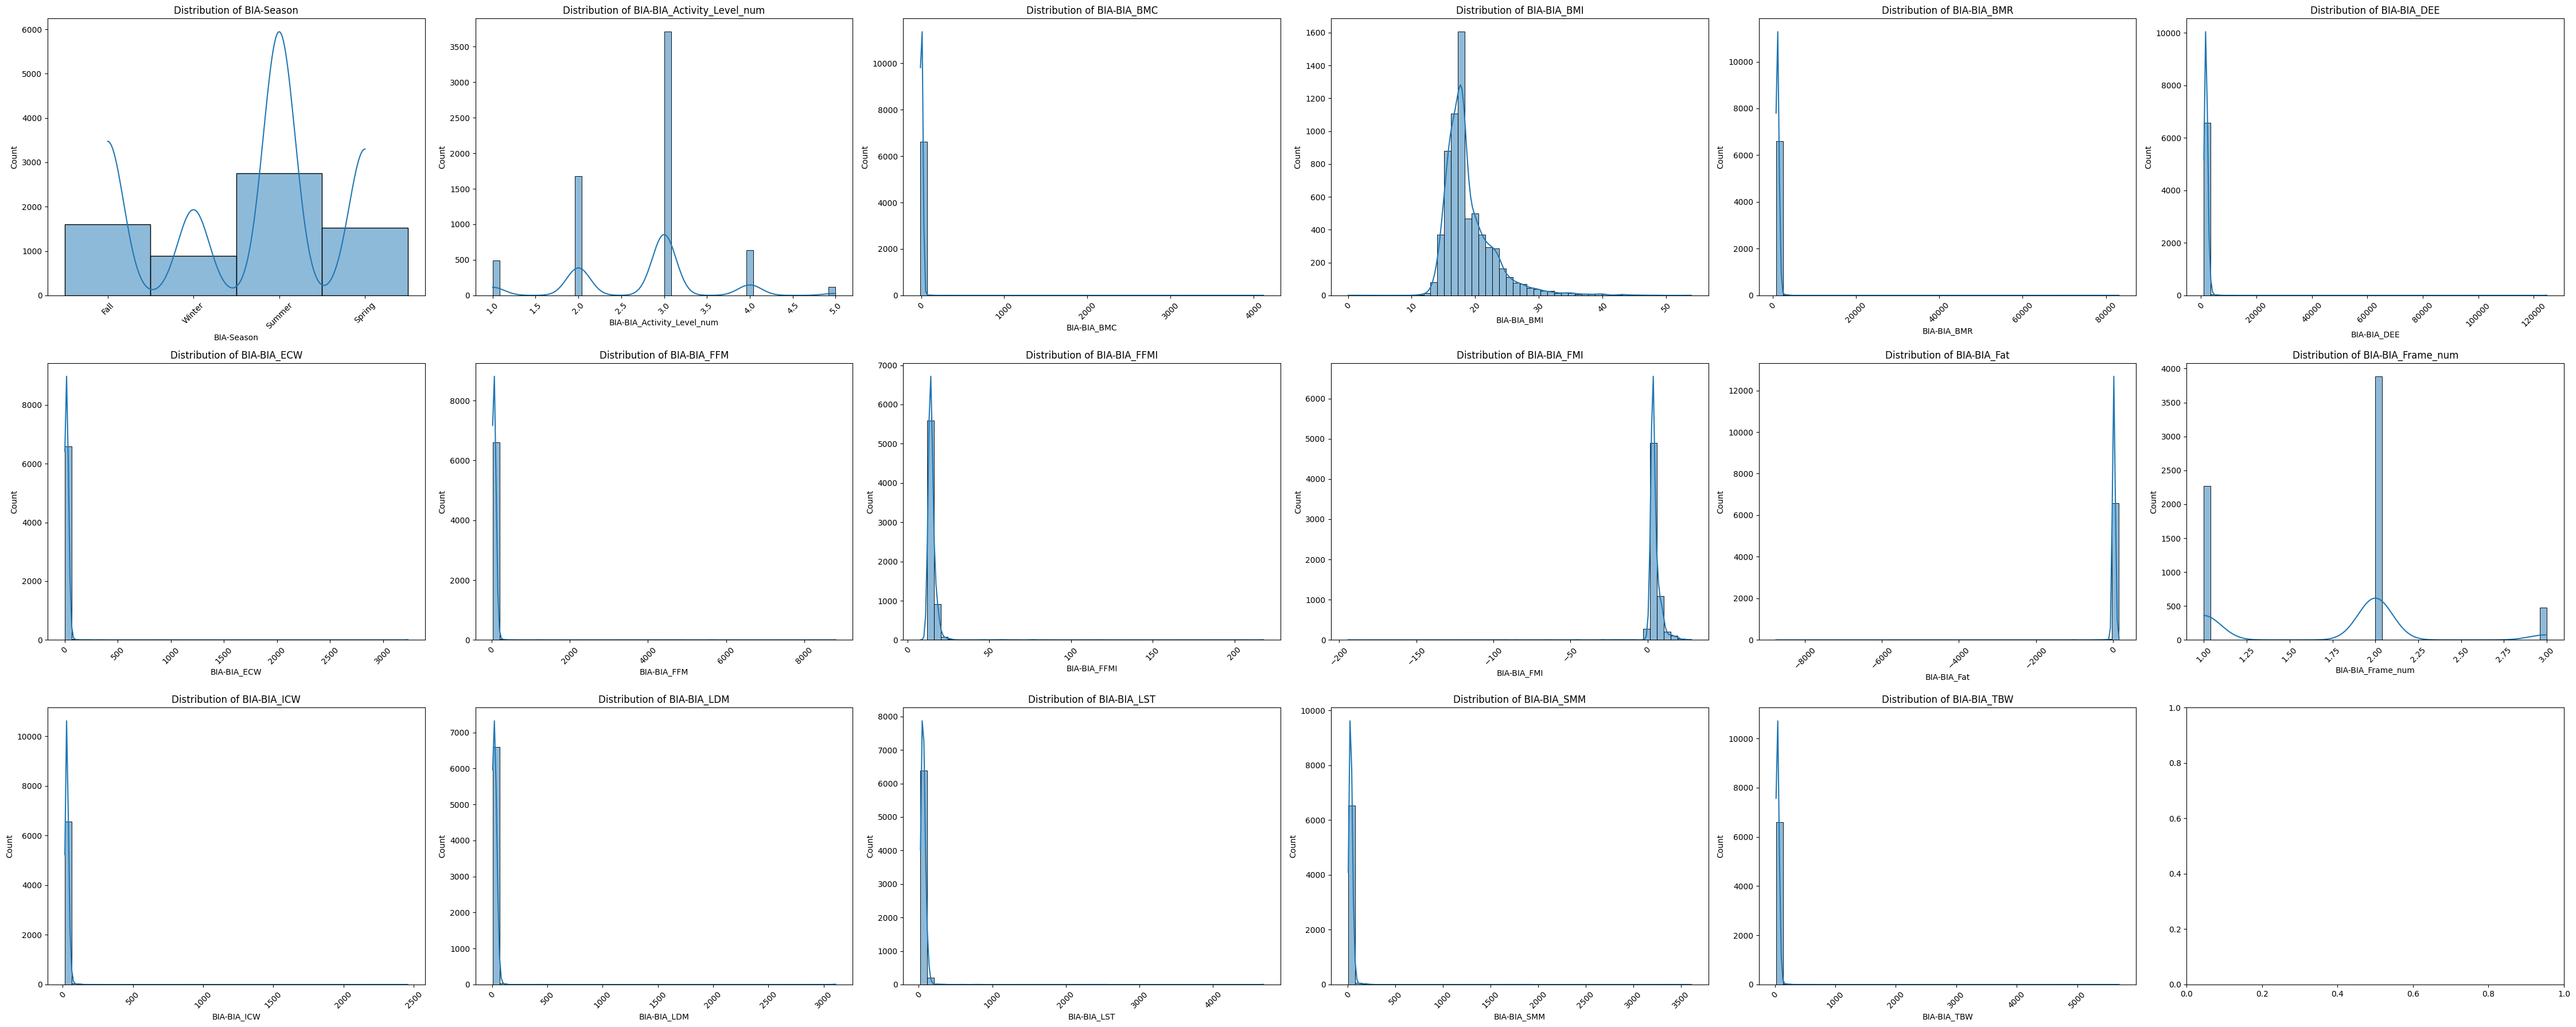

In [35]:
#Controllo distribuzioni variabili BIA
bia_vars = [col for col in df.columns if 'BIA' in col]
fig, axes = plt.subplots(3,6, figsize=(45, 18))
for i, var in enumerate(bia_vars):
    sns.histplot(df[var], bins=50, kde=True, ax=axes[i//6, i%6])
    axes[i//6, i%6].set_title(f'Distribution of {var}')
    axes[i//6, i%6].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [36]:
(df['BIA-BIA_FMI'] < 0).sum()

np.int64(51)

In [37]:
(df['BIA-BIA_BMC'] < 0).sum()
  

np.int64(34)

In [38]:
(df['BIA-BIA_Fat'] < 0).sum()
  

np.int64(112)

In [39]:
(df['BIA-BIA_BMR'] > 5000).sum()

np.int64(8)

In [40]:
(df['BIA-BIA_TBW'] < 0).sum()

np.int64(0)

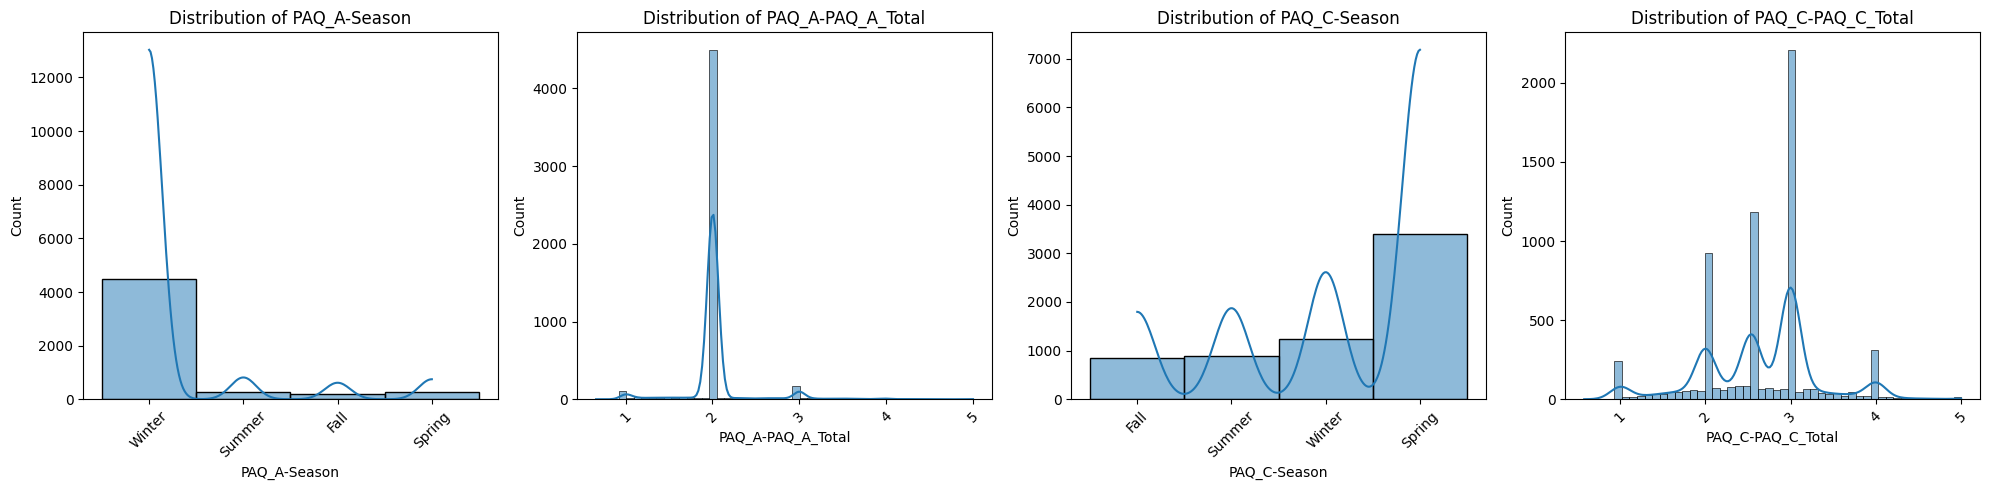

In [41]:
#controllo le variabili delle distribuzioni PAQ
paqvars = [col for col in df.columns if 'PAQ' in col]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, var in enumerate(paqvars):
    sns.histplot(df[var], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {var}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

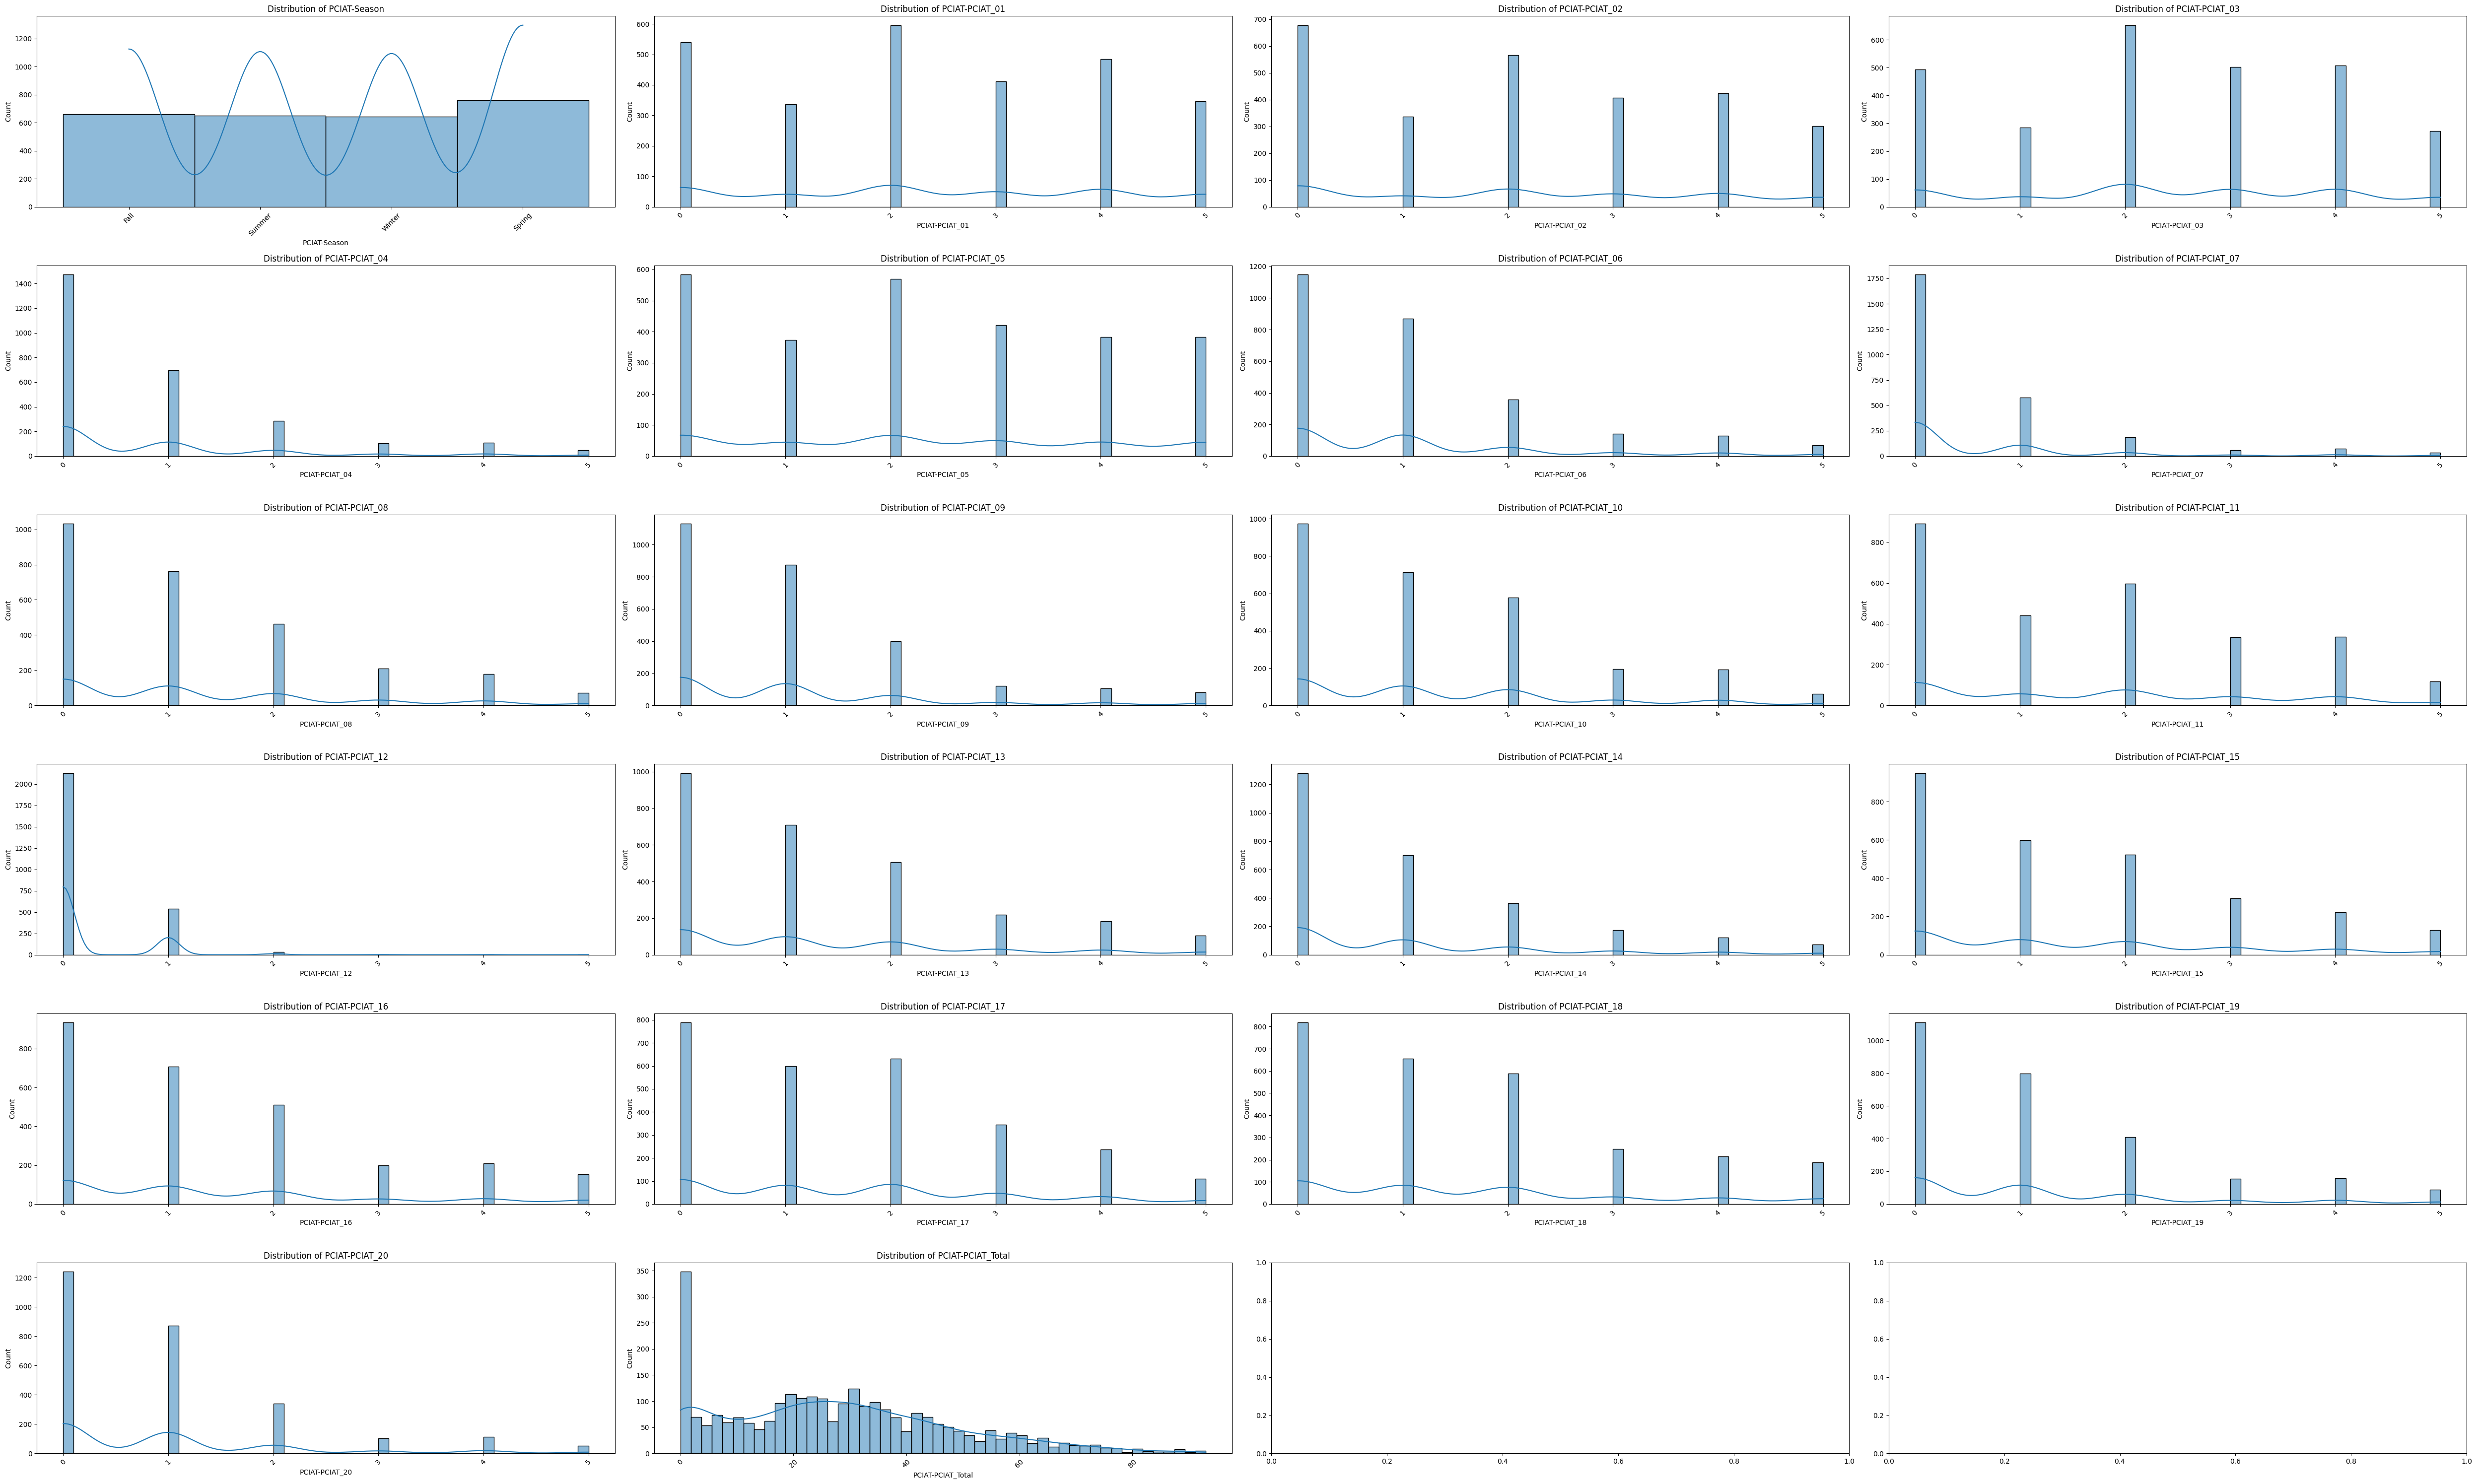

In [42]:
pciatvars = [col for col in df.columns if 'PCIAT' in col]
fig, axes = plt.subplots(6, 4, figsize=(50, 30))
for i, var in enumerate(pciatvars):
    sns.histplot(df[var], bins=50, kde=True, ax=axes[i//4, i%4])
    axes[i//4, i%4].set_title(f'Distribution of {var}')
    axes[i//4, i%4].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

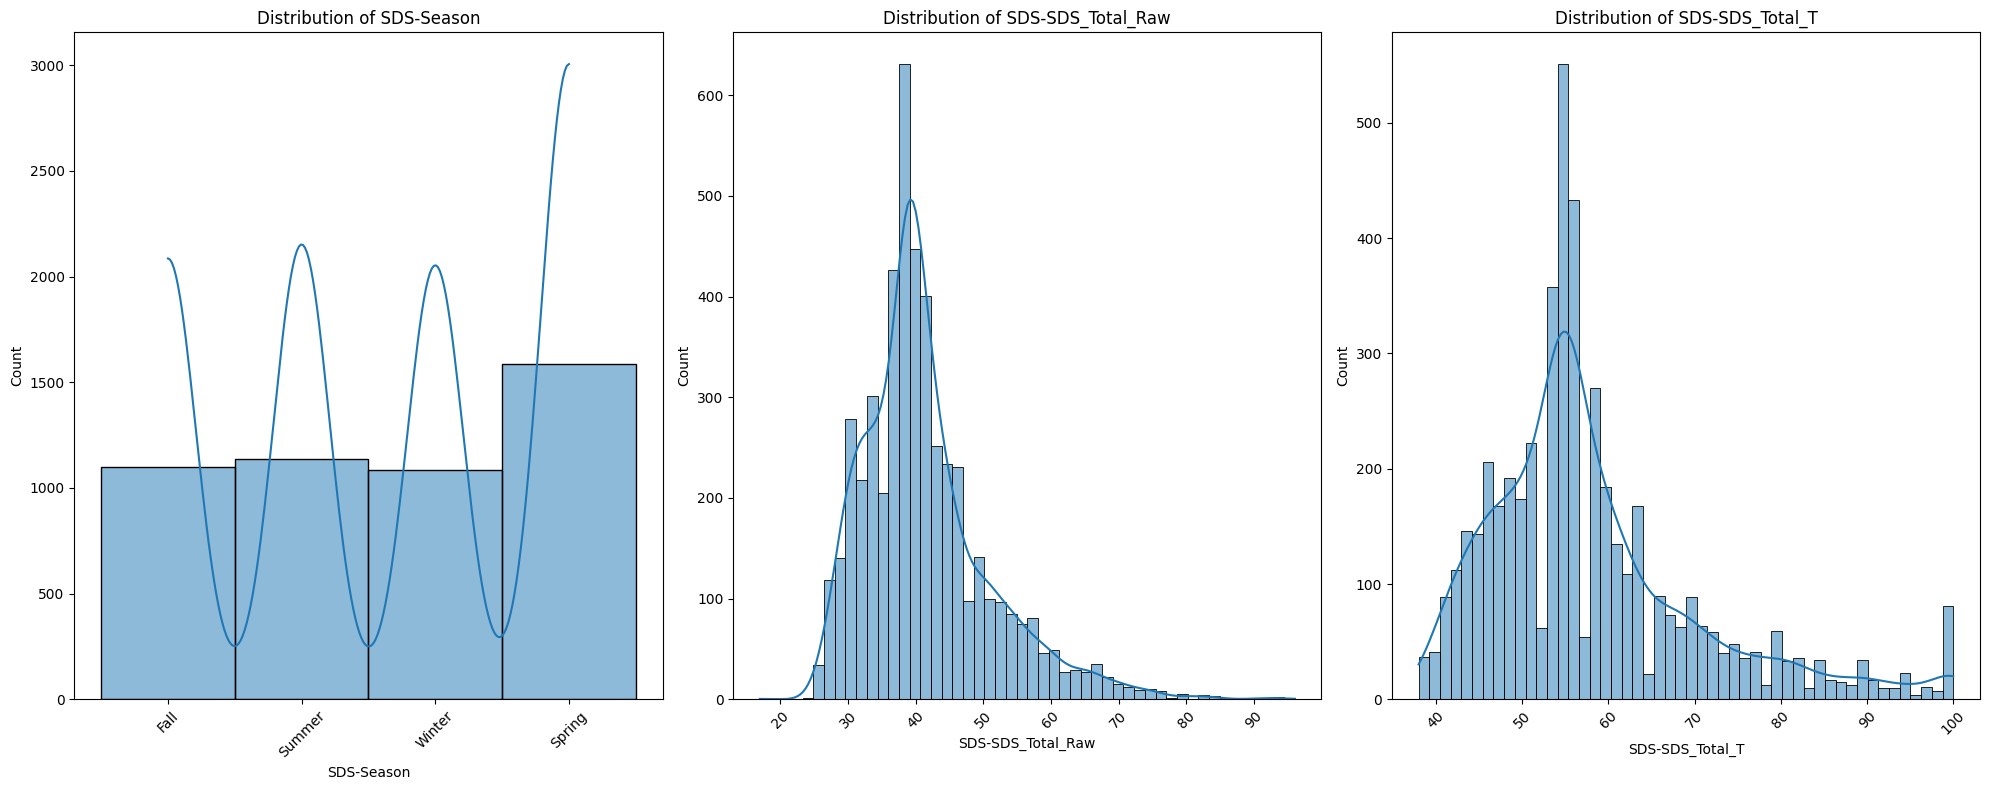

In [43]:
#Controllo distribuzioni SDS
sdsvars = [col for col in df.columns if 'SDS' in col]
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for i, var in enumerate(sdsvars):
    sns.histplot(df[var], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {var}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()



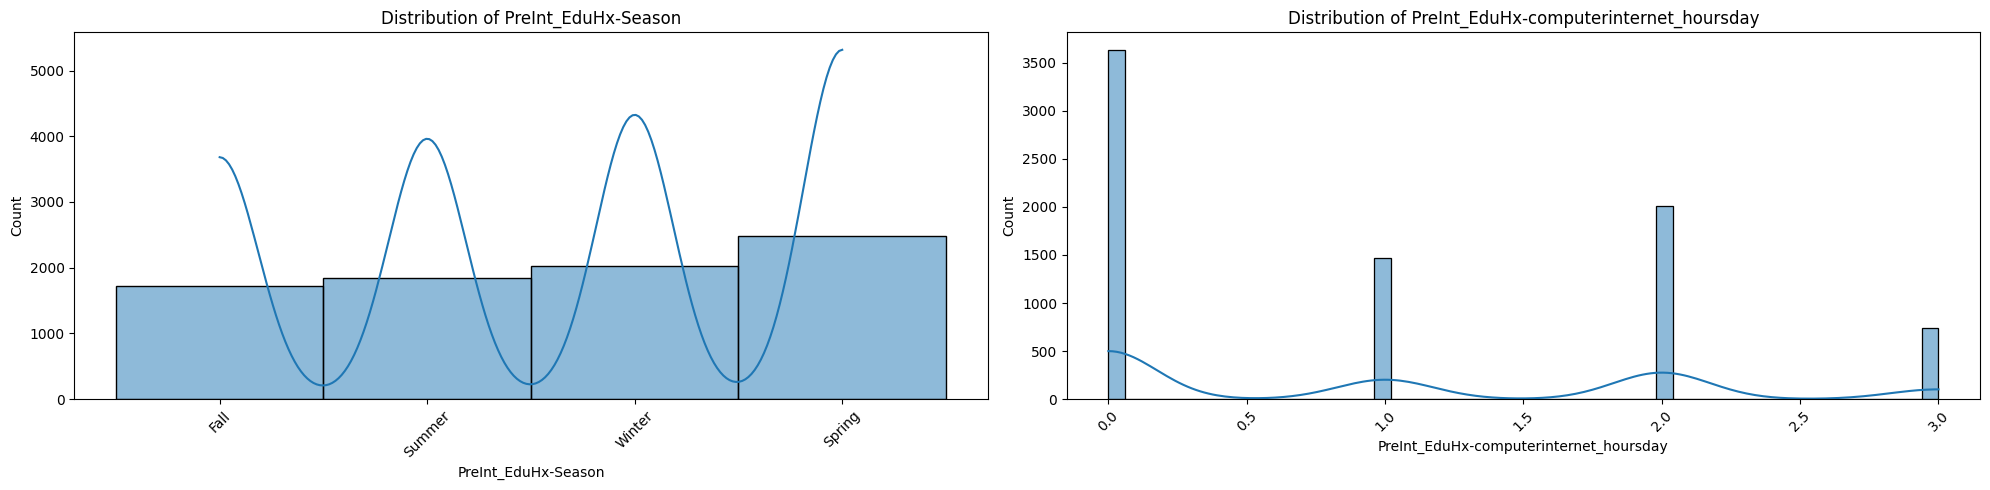

In [44]:
#controllo variabili PreInt
preintvars = [col for col in df.columns if 'PreInt' in col]
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
for i, var in enumerate(preintvars):
    sns.histplot(df[var], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {var}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


In [45]:
#isolo le colonne PCIAT
df_pciat = df[[col for col in df.columns if 'PCIAT' in col]]


In [46]:
df_pciat = df_pciat.drop(columns = ['PCIAT-Season'])

In [47]:
#droppo colonne Season
df_corr = df.drop(columns = [col for col in df.columns if 'Season' in col])

In [48]:
df_corr = df_corr.drop(columns = ['id'] + ['sii'] + ['PreInt_EduHx-computerinternet_hoursday'] + [col for col in df_corr.columns if col.startswith('SDS')])

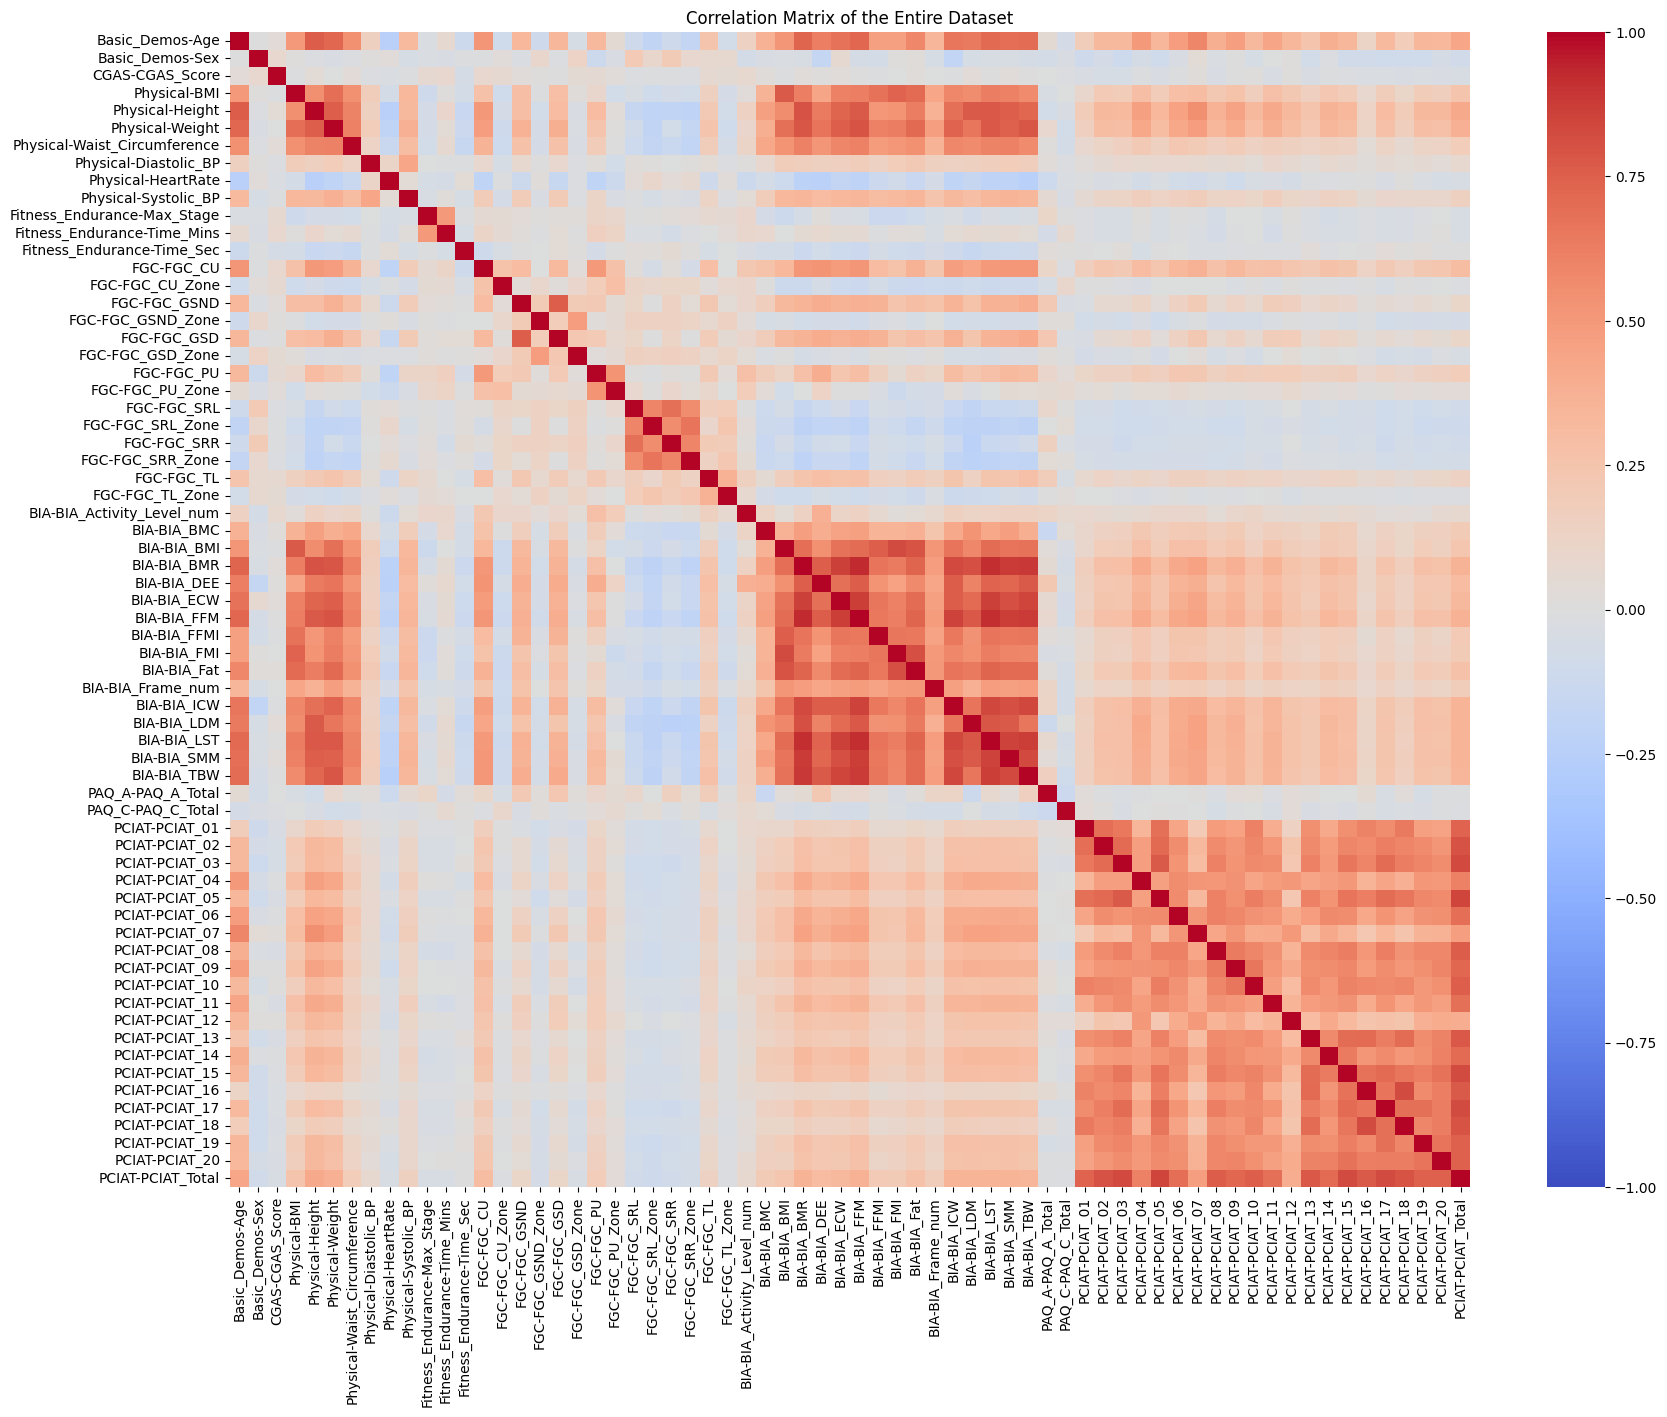

In [49]:
#faccio la correlation matrix dell'intero dataset
plt.figure(figsize=(20, 15))
sns.heatmap(df_corr.corr(method='spearman'), annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of the Entire Dataset')
plt.show()


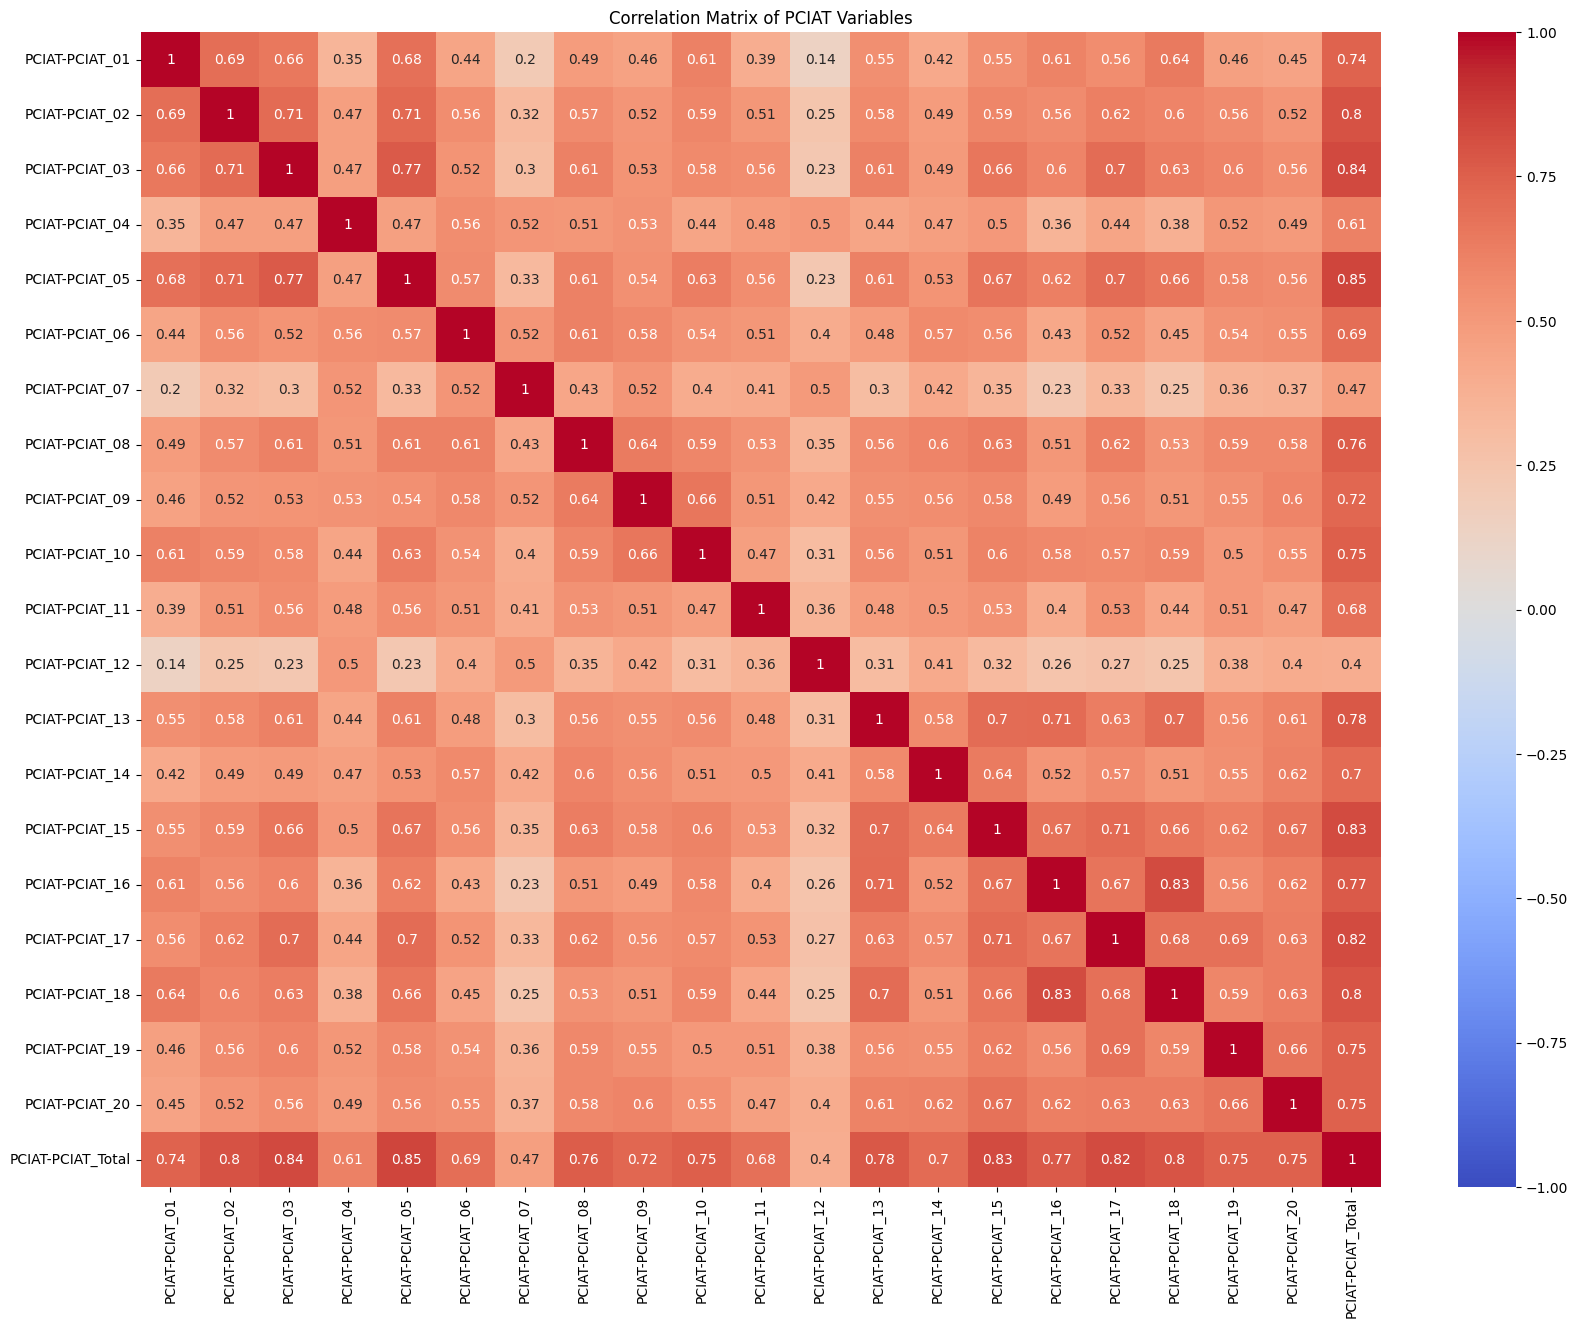

In [50]:
#correlzione di df_pciat
plt.figure(figsize=(20, 15))
sns.heatmap(df_pciat.corr(method='spearman'), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of PCIAT Variables')
plt.show()

In [51]:
#correlazione tra le colonne PCIAT e il target sii (sii viene escluso da df_corr, quindi va controllato a parte)
pciat_sii = df[[c for c in df.columns if 'PCIAT' in c and 'Season' not in c] + ['sii']].corr(method='spearman')['sii'].drop('sii')
print(pciat_sii.sort_values(ascending=False).round(2))

#verifica: sii coincide con PCIAT_Total diviso in fasce?
fasce = pd.cut(df['PCIAT-PCIAT_Total'], [-1, 30, 49, 79, 200], labels=[0, 1, 2, 3]).astype(float)
presente = df['PCIAT-PCIAT_Total'].notna()
print(f"\nsii coincide con le fasce di PCIAT_Total nel {(fasce[presente] == df.loc[presente, 'sii']).mean()*100:.1f}% delle righe")
print(f"Righe con sii presente ma PCIAT mancante: {(~presente & df['sii'].notna()).sum()}")

PCIAT-PCIAT_Total    0.88
PCIAT-PCIAT_05       0.73
PCIAT-PCIAT_15       0.72
PCIAT-PCIAT_03       0.71
PCIAT-PCIAT_17       0.70
PCIAT-PCIAT_02       0.69
PCIAT-PCIAT_18       0.69
PCIAT-PCIAT_13       0.67
PCIAT-PCIAT_20       0.65
PCIAT-PCIAT_16       0.65
PCIAT-PCIAT_08       0.65
PCIAT-PCIAT_19       0.64
PCIAT-PCIAT_10       0.64
PCIAT-PCIAT_01       0.62
PCIAT-PCIAT_09       0.62
PCIAT-PCIAT_14       0.61
PCIAT-PCIAT_06       0.59
PCIAT-PCIAT_11       0.59
PCIAT-PCIAT_04       0.54
PCIAT-PCIAT_07       0.41
PCIAT-PCIAT_12       0.35
Name: sii, dtype: float64

sii coincide con le fasce di PCIAT_Total nel 99.8% delle righe
Righe con sii presente ma PCIAT mancante: 5746


In [52]:
#calcolo la correlazione tra Physical-BMI e BIA-BIA_BMI
correlation = df['Physical-BMI'].corr(df['BIA-BIA_BMI'])
print(f"Correlation between Physical-BMI and BIA-BIA_BMI: {correlation:.2f}")

Correlation between Physical-BMI and BIA-BIA_BMI: 0.68


Il BMI fisico e quello BIA dovrebbero coincidere quasi perfettamente, ma la correlazione è solo 0,68: è un primo segnale che almeno una delle due colonne contiene valori incoerenti (vedi il controllo di coerenza del BMI più sopra).

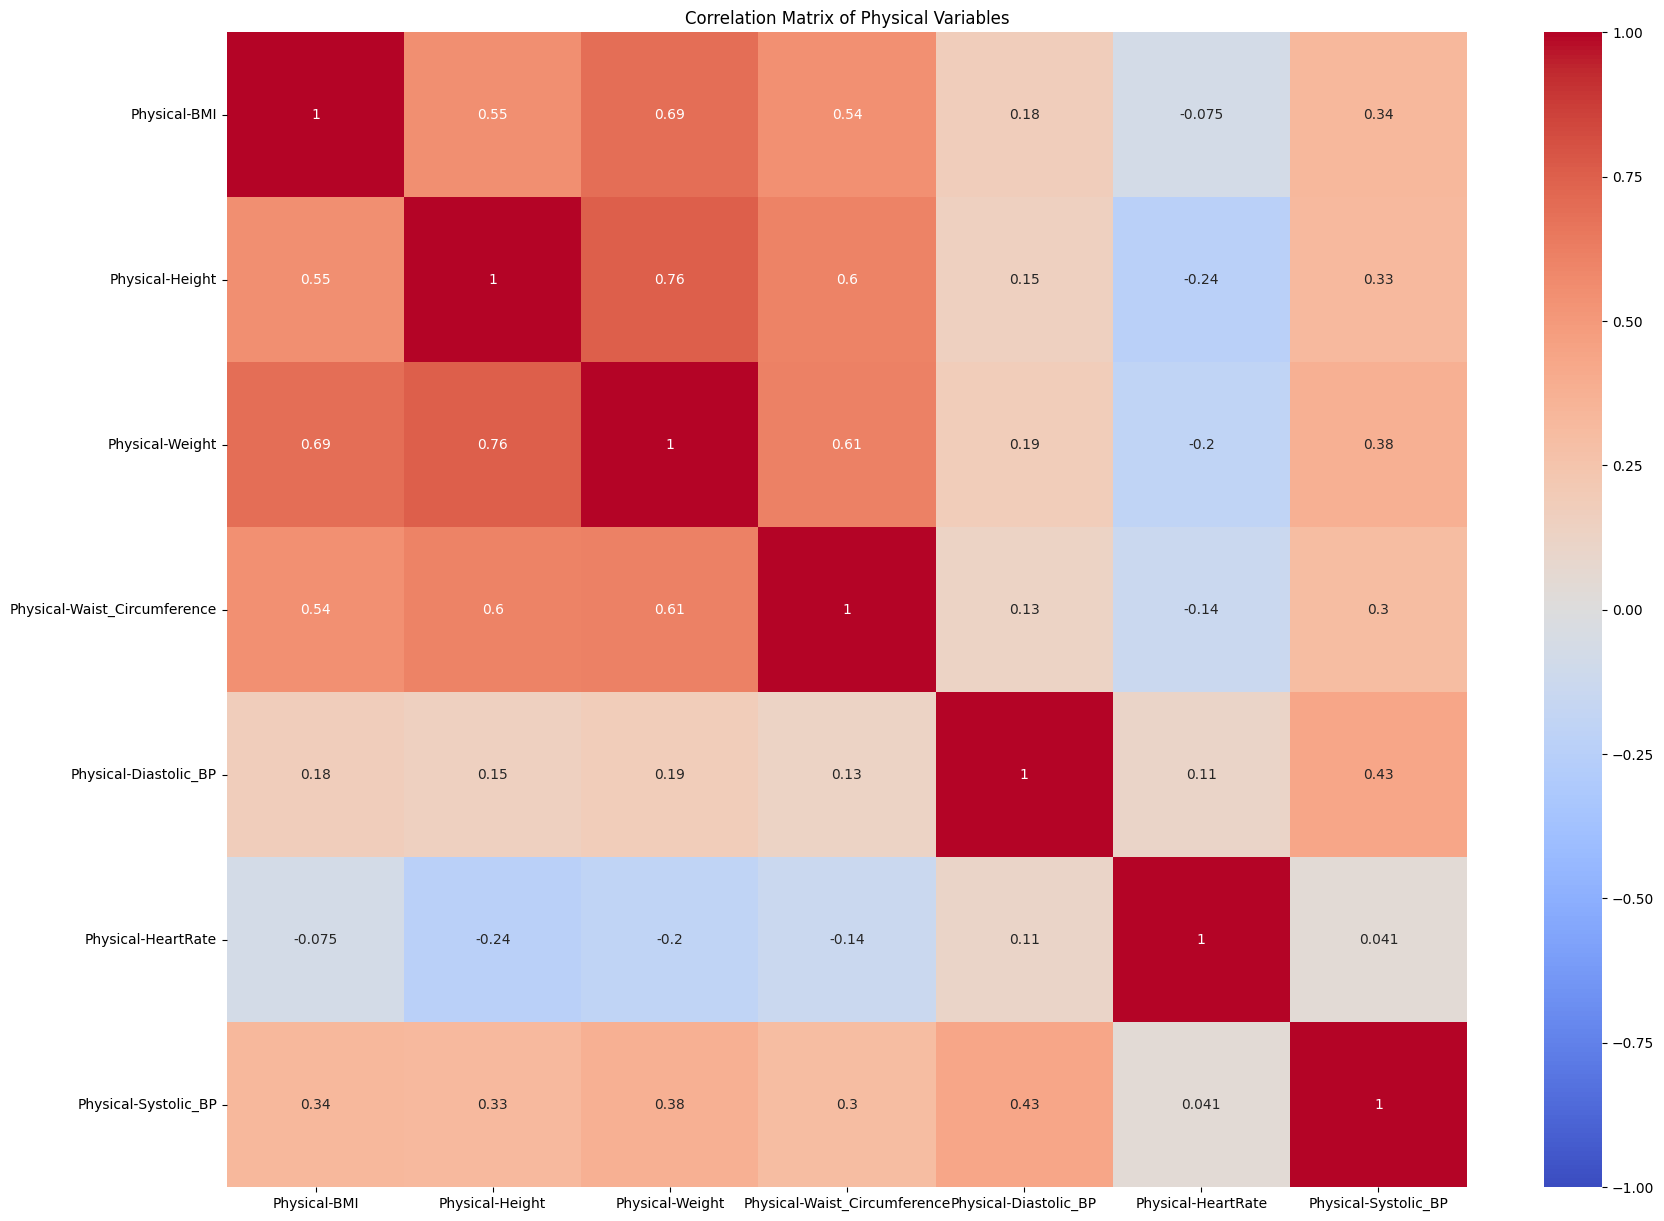

In [53]:
#isolo le variabili Physical
physical_vars = [col for col in df_corr.columns if 'Physical' in col]
plt.figure(figsize=(20, 15))
sns.heatmap(df_corr[physical_vars].corr(method='spearman'), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Physical Variables')
plt.show()

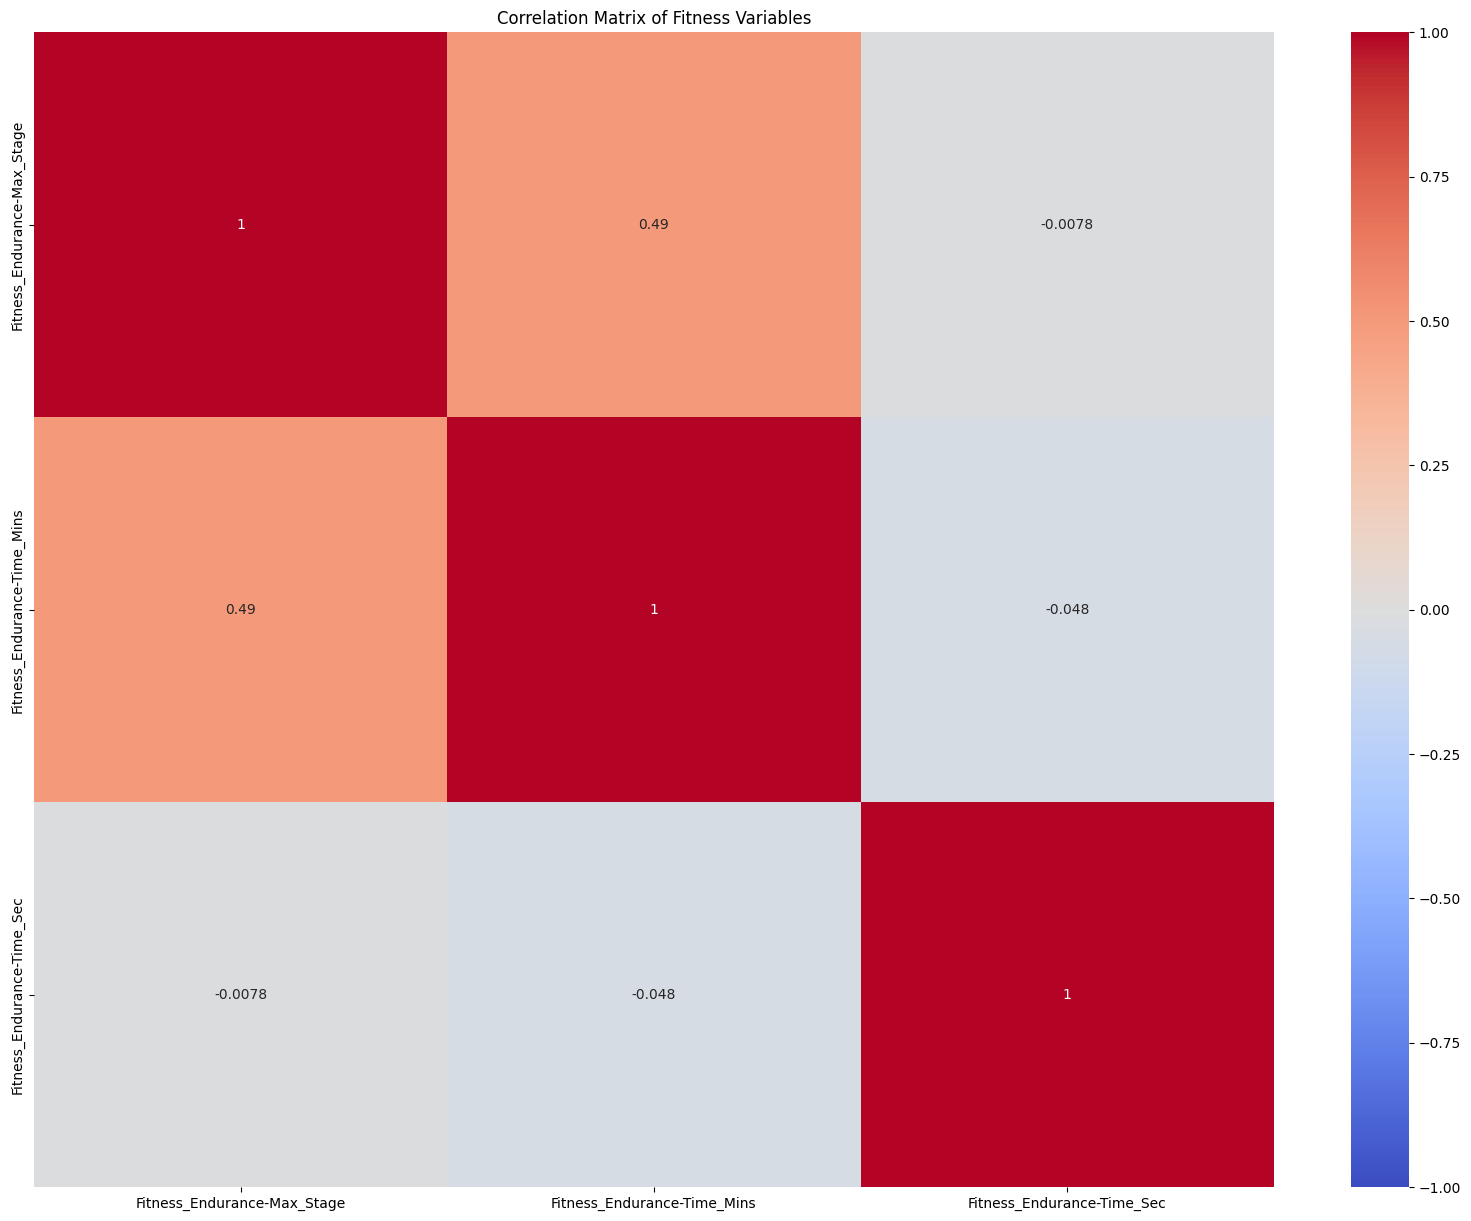

In [54]:
#isolo le variabili Fitness
fitness_vars = [col for col in df_corr.columns if 'Fitness' in col]
plt.figure(figsize=(20, 15))
sns.heatmap(df_corr[fitness_vars].corr(method='spearman'), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Fitness Variables')
plt.show()

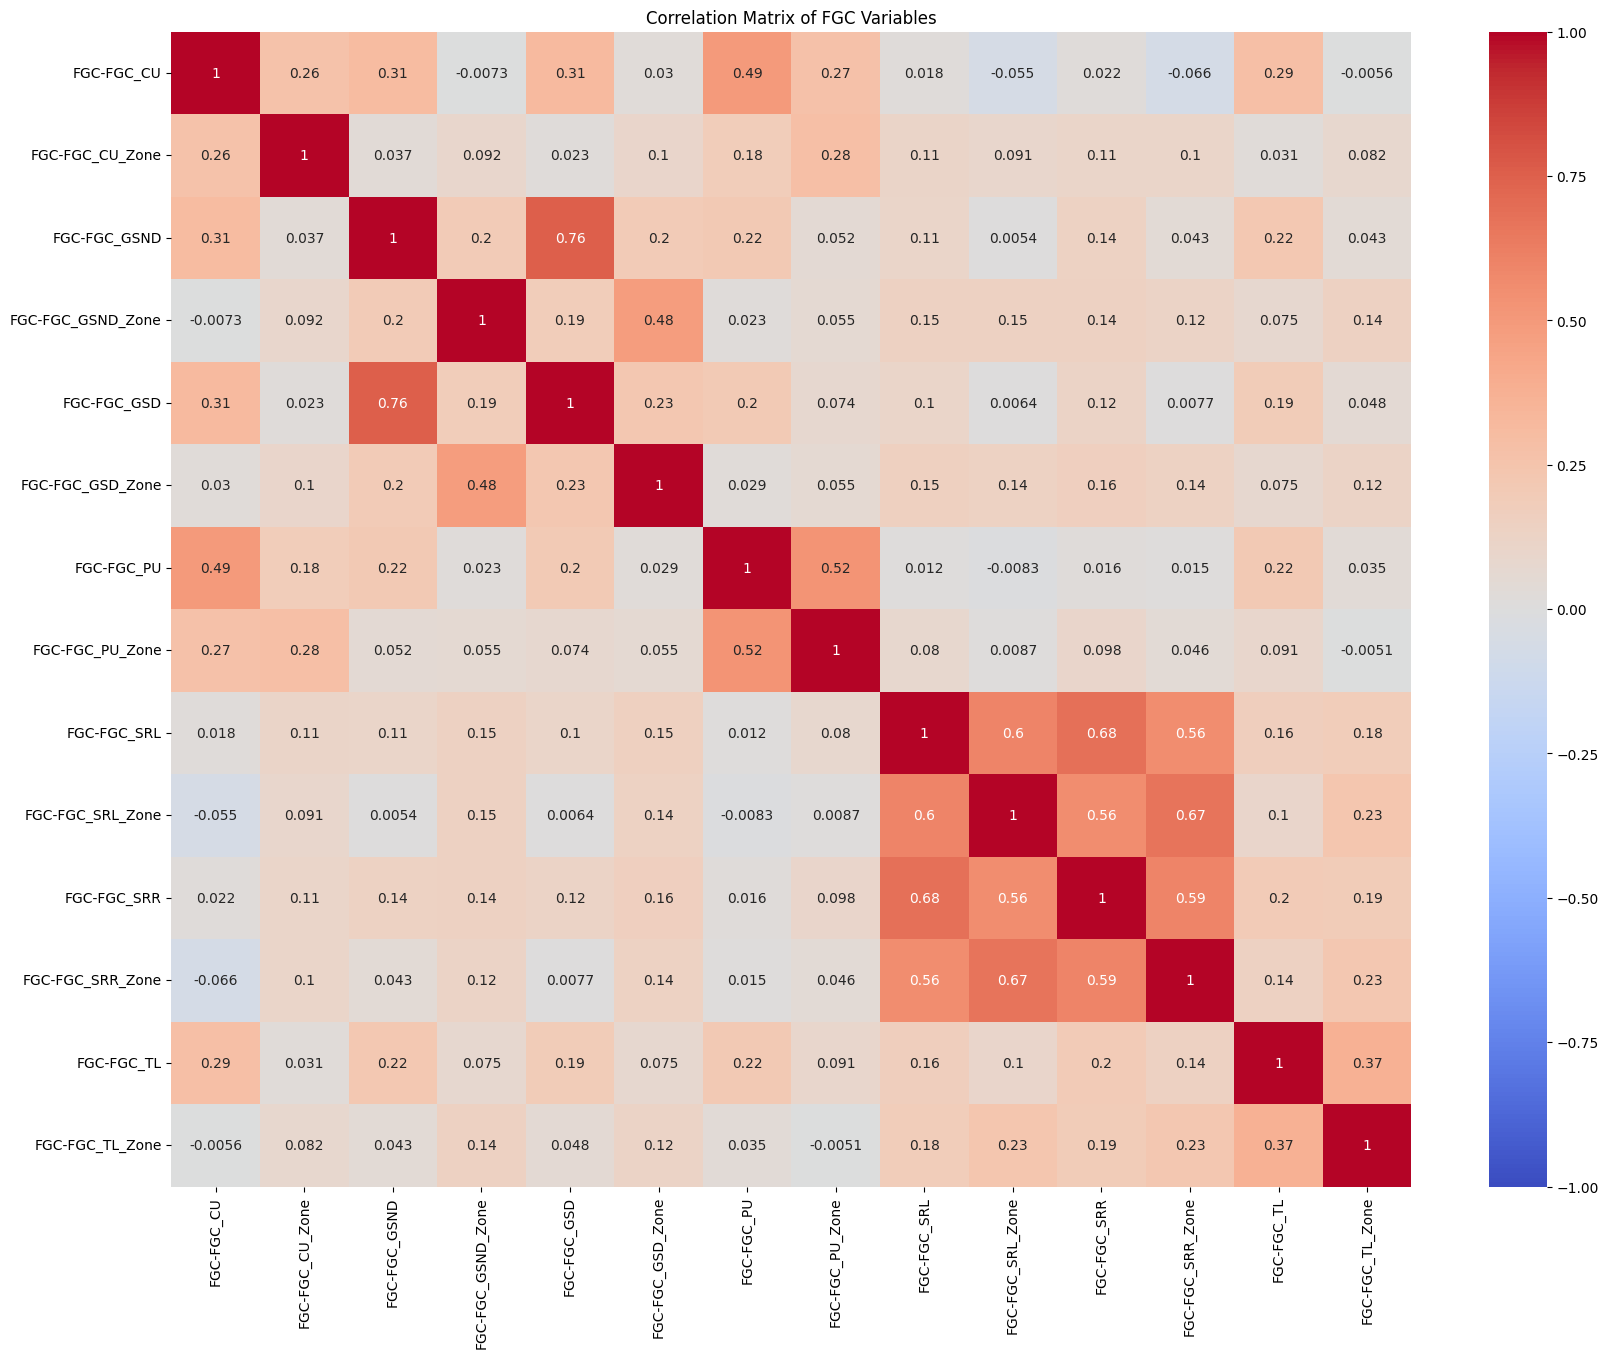

In [55]:
#isolo le variabili FGC
fgc_vars = [col for col in df_corr.columns if 'FGC' in col]
plt.figure(figsize=(20, 15))
sns.heatmap(df_corr[fgc_vars].corr(method='spearman'), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of FGC Variables')
plt.show()

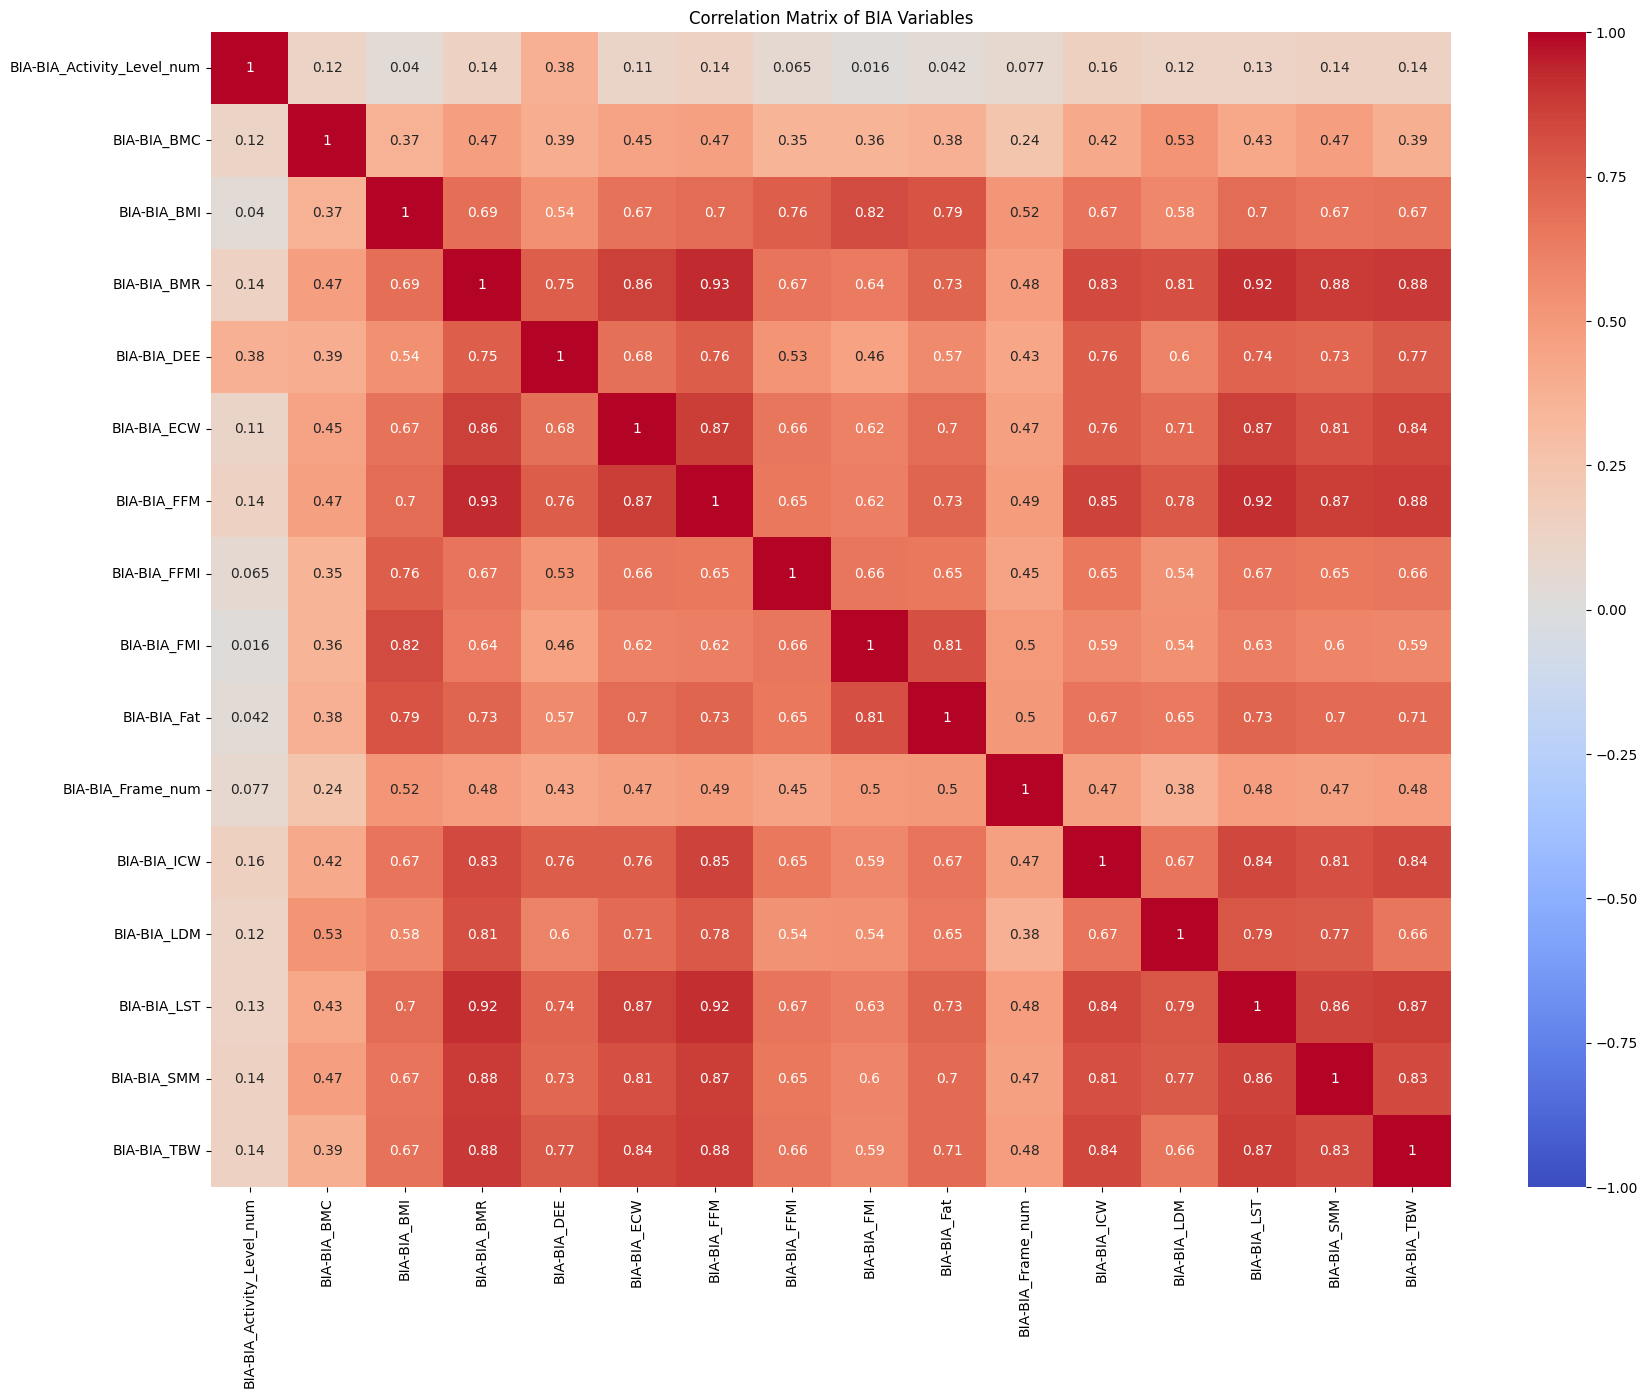

In [56]:
#isolole variabili BIA
bia_vars = [col for col in df_corr.columns if 'BIA' in col]
plt.figure(figsize=(20, 15))
sns.heatmap(df_corr[bia_vars].corr(method='spearman'), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of BIA Variables')
plt.show()

In [57]:
df_corr =df_corr.drop(columns = [col for col in df_corr.columns if 'BIA' in col])

In [58]:
df_corr =df_corr.drop(columns = [col for col in df_corr.columns if 'Physical' in col])

In [59]:
df_corr =df_corr.drop(columns = [col for col in df_corr.columns if 'FGC' in col])

In [60]:
df_corr = df_corr.drop(columns=[col for col in df_corr.columns if 'Fitness' in col])

In [61]:
df_corr = df_corr.drop(columns=[col for col in df_corr.columns if 'PCIAT' in col])

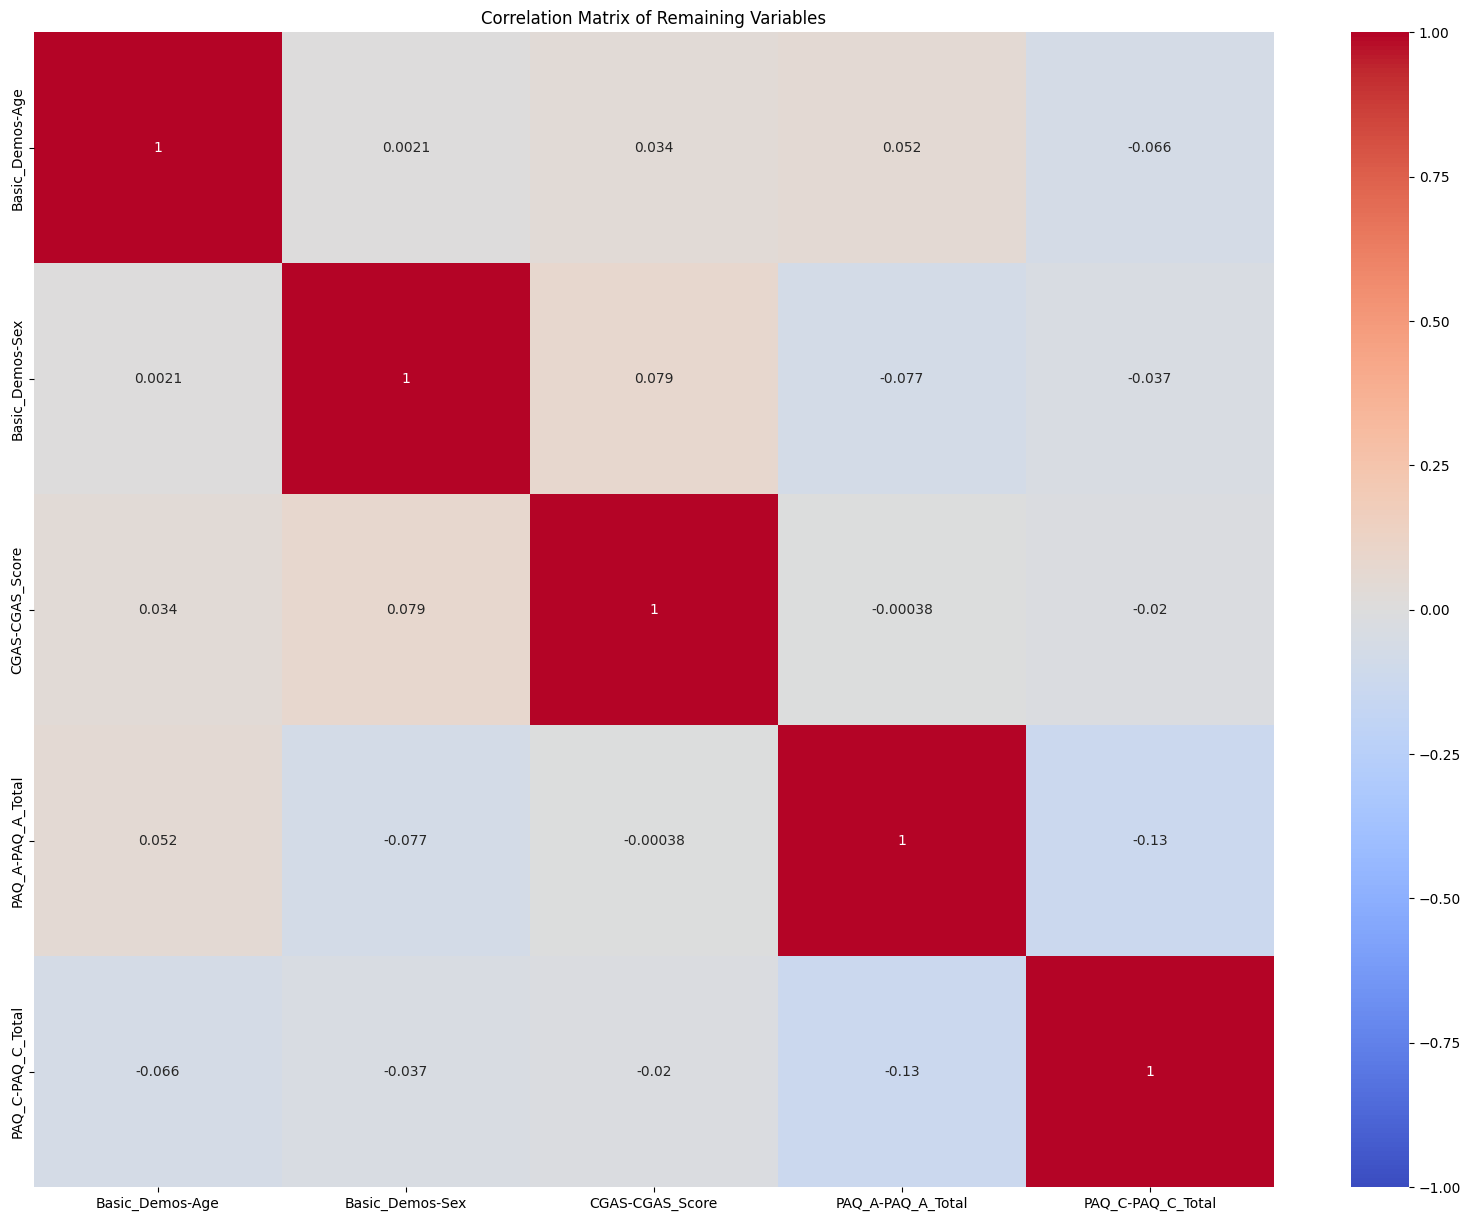

In [62]:
#correlazioni di df_corr
plt.figure(figsize=(20, 15))
sns.heatmap(df_corr.corr(method='spearman'), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Remaining Variables')
plt.show()

In [63]:
#controllo in che percentuali valori di Physical-Waist_Circumference sono missing e in che percentuale assumono un valore di 26, escludendo i missing
missing_percentage = (df['Physical-Waist_Circumference'].isnull().sum() / len(df)) * 100
equal_to_26_percentage = ((df['Physical-Waist_Circumference'] == 26.0) & (df['Physical-Waist_Circumference'].notnull())).sum() / len(df) * 100
missing_percentage, equal_to_26_percentage


(np.float64(33.522458628841605), np.float64(19.30260047281324))

###IL FILE SI CHIAMA DATA UNDERSTANDING, MA IN REALTA' DA QUA INIZIAMO LA DATA PREPARATION.

In [64]:
#converto i valori di CGAS-CGAS_Score superiori a 100 in NaN
df.loc[df['CGAS-CGAS_Score'] > 100, 'CGAS-CGAS_Score'] = np.nan

In [65]:
df.loc[df['Physical-Weight'] == 0, 'Physical-Weight'] = np.nan

In [66]:
df.loc[df['Physical-BMI'] == 0, 'Physical-BMI'] = np.nan

In [67]:
#controllo se ci sono righe con Diastolic_BP uguale a 0 e Systolic_BP uguale a 0 contemporaneamente
((df['Physical-Diastolic_BP'] == 0) & (df['Physical-Systolic_BP'] == 0)).sum()


np.int64(1)

In [68]:
#converto i valori di diastolic_BP e systolic_BP uguali a 0 in NaN
df.loc[(df['Physical-Diastolic_BP'] == 0) & (df['Physical-Systolic_BP'] == 0), ['Physical-Diastolic_BP', 'Physical-Systolic_BP']] = np.nan

In [69]:
#pressione sistolica <= diastolica: fisiologicamente impossibile, non sappiamo quale delle due sia errata -> NaN su entrambe
mask_bp = df['Physical-Systolic_BP'] <= df['Physical-Diastolic_BP']
print("Righe con Systolic <= Diastolic:", mask_bp.sum())
df.loc[mask_bp, ['Physical-Diastolic_BP', 'Physical-Systolic_BP']] = np.nan

Righe con Systolic <= Diastolic: 12


In [70]:
#Fitness_Endurance: minuti e secondi sono due parti dello STESSO tempo.
#Time_Sec == 0 è valido (es. 8'00"), così come Time_Mins == 0 con secondi > 0 (test sotto il minuto).
#È impossibile solo un tempo TOTALE pari a 0.
tempo_tot = df['Fitness_Endurance-Time_Mins'] * 60 + df['Fitness_Endurance-Time_Sec']
print("Righe con Time_Sec == 0 e Time_Mins > 0 (valide):", ((df['Fitness_Endurance-Time_Sec'] == 0) & (df['Fitness_Endurance-Time_Mins'] > 0)).sum())
print("Righe con Time_Mins == 0 e Time_Sec > 0 (valide):", ((df['Fitness_Endurance-Time_Mins'] == 0) & (df['Fitness_Endurance-Time_Sec'] > 0)).sum())
print("Righe con tempo totale == 0 (impossibili):", (tempo_tot == 0).sum())
df.loc[tempo_tot == 0, ['Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec']] = np.nan
df.loc[df['Fitness_Endurance-Max_Stage'] == 0, 'Fitness_Endurance-Max_Stage'] = np.nan

Righe con Time_Sec == 0 e Time_Mins > 0 (valide): 73
Righe con Time_Mins == 0 e Time_Sec > 0 (valide): 28
Righe con tempo totale == 0 (impossibili): 0


In [71]:
#controllo i valori di BIA-BIA_BMC negativi e quelli sopra il 20
print("Numero di valori di BIA-BIA_BMC negativi:", (df['BIA-BIA_BMC'] < 0).sum())
print("Numero di valori di BIA-BIA_BMC superiori a 20:", (df['BIA-BIA_BMC'] > 20).sum())


Numero di valori di BIA-BIA_BMC negativi: 34
Numero di valori di BIA-BIA_BMC superiori a 20: 45


In [72]:
#converto i valori di BIA-BIA_BMC negativi e quelli sopra il 20 in NaN
df.loc[(df['BIA-BIA_BMC'] < 0) | (df['BIA-BIA_BMC'] > 20), 'BIA-BIA_BMC'] = np.nan

In [73]:
#converto in naN i valori di BIA-BIA_BMR superiori a 5000
df.loc[df['BIA-BIA_BMR'] > 5000, 'BIA-BIA_BMR'] = np.nan

In [74]:
#converto in nan i valori di BIA-BIA_FMI negativi e BIA-BIA_Fat negativi
df.loc[df['BIA-BIA_FMI'] < 0, 'BIA-BIA_FMI'] = np.nan
df.loc[df['BIA-BIA_Fat'] < 0, 'BIA-BIA_Fat'] = np.nan

### Valori impossibili: peso e componenti BIA
Nel data understanding mettiamo a NaN **solo i valori fisicamente impossibili**, individuati con regole di dominio. I valori estremi ma plausibili restano nel dataset e vengono gestiti nel modulo di outlier detection.

- **Peso < 20 lb**: nessun partecipante (età minima 5 anni) può pesare meno di 20 lb (circa 9 kg).
- **Componenti di massa BIA** (FFM, TBW, ECW, ICW, LST, SMM, LDM, BMC, Fat): una parte del corpo non può pesare più del corpo intero. Usiamo una tolleranza di 2x il peso per assorbire l'errore di misura del peso.
- **FFMI > 2x BIA_BMI**: FFMI è l'indice di massa magra, che non può superare l'indice di massa totale.
- **DEE > 10000 kcal**: coerente con la soglia già usata per BMR (DEE ≈ BMR x fattore di attività ≤ 2).

In [75]:
#peso sotto le 20 lb: impossibile per qualsiasi età del campione (5-22 anni)
print("Peso < 20 lb (esclusi gli 0 già trattati):", (df['Physical-Weight'] < 20).sum())
df.loc[df['Physical-Weight'] < 20, 'Physical-Weight'] = np.nan

Peso < 20 lb (esclusi gli 0 già trattati): 19


In [76]:
#regola: una componente di massa BIA non può superare il peso corporeo (tolleranza 1.2x)
FATTORE_TOLLERANZA = 1.2
mass_cols = ['BIA-BIA_FFM', 'BIA-BIA_TBW', 'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_LST',
             'BIA-BIA_SMM', 'BIA-BIA_LDM', 'BIA-BIA_BMC', 'BIA-BIA_Fat']
peso = df['Physical-Weight']
tot_bia = 0
for col in mass_cols:
    mask = df[col] > FATTORE_TOLLERANZA * peso
    print(f"{col}: {mask.sum()} valori > {FATTORE_TOLLERANZA}x peso")
    df.loc[mask, col] = np.nan
    tot_bia += mask.sum()

mask_ffmi = df['BIA-BIA_FFMI'] > FATTORE_TOLLERANZA * df['BIA-BIA_BMI']
print(f"BIA-BIA_FFMI: {mask_ffmi.sum()} valori > {FATTORE_TOLLERANZA}x BIA_BMI")
df.loc[mask_ffmi, 'BIA-BIA_FFMI'] = np.nan

mask_dee = df['BIA-BIA_DEE'] > 10000
print(f"BIA-BIA_DEE: {mask_dee.sum()} valori > 10000 kcal")
df.loc[mask_dee, 'BIA-BIA_DEE'] = np.nan
print("Totale celle BIA messe a NaN in questa cella:", tot_bia + mask_ffmi.sum() + mask_dee.sum())

BIA-BIA_FFM: 302 valori > 1.2x peso
BIA-BIA_TBW: 59 valori > 1.2x peso
BIA-BIA_ECW: 25 valori > 1.2x peso
BIA-BIA_ICW: 24 valori > 1.2x peso
BIA-BIA_LST: 246 valori > 1.2x peso
BIA-BIA_SMM: 47 valori > 1.2x peso
BIA-BIA_LDM: 20 valori > 1.2x peso
BIA-BIA_BMC: 0 valori > 1.2x peso
BIA-BIA_Fat: 25 valori > 1.2x peso
BIA-BIA_FFMI: 52 valori > 1.2x BIA_BMI
BIA-BIA_DEE: 12 valori > 10000 kcal
Totale celle BIA messe a NaN in questa cella: 812


In [77]:
#controllo: massimi delle colonne BIA dopo la pulizia
df[[c for c in df.columns if c.startswith('BIA') and df[c].dtype != object]].describe().T[['50%', 'max']].round(1)

,50%,max
BIA-BIA_Activity_Level_num,3.0,5.0
BIA-BIA_BMC,4.2,18.9
BIA-BIA_BMI,18.0,53.9
BIA-BIA_BMR,1115.4,4373.7
BIA-BIA_DEE,1821.4,7994.1
BIA-BIA_ECW,15.9,225.2
BIA-BIA_FFM,61.1,220.9
BIA-BIA_FFMI,14.1,84.5
BIA-BIA_FMI,3.7,28.3
BIA-BIA_Fat,16.2,153.8


In [78]:
# 1. Eliminiamo valori di pressione fisiologicamente impossbili: diastolica < 30, sistolica < 60
df.loc[df['Physical-Diastolic_BP'] < 30, 'Physical-Diastolic_BP'] = np.nan
df.loc[df['Physical-Systolic_BP'] < 60, 'Physical-Systolic_BP'] = np.nan

# 2. Forza di presa: 0 = test non eseguito
for c in ['FGC-FGC_GSND', 'FGC-FGC_GSD']:
    df.loc[df[c] == 0, c] = np.nan

# 3. Treadmill, vedendo il test del tapis roulant effettuato in questo studio, il numero massimo di stage possibile è 10
df.loc[df['Fitness_Endurance-Max_Stage'] > 10, 'Fitness_Endurance-Max_Stage'] = np.nan

# 4. DEE non può stare sotto il metabolismo basale, eprchè e il dispendio energetico giornaliero, dato dal BMR + l'attività fisica.
df.loc[df['BIA-BIA_DEE'] < df['BIA-BIA_BMR'], 'BIA-BIA_DEE'] = np.nan

In [79]:
#converto il dataset in csv
df.to_csv('cmi_internet_da_classificare.csv', index=False)

In [80]:
df = pd.read_csv('cmi_internet_da_classificare.csv')

In [81]:
df.isnull().sum()
df.isnull().sum() / len(df) * 100

id                                         0.000000
Basic_Demos-Enroll_Season                  0.000000
Basic_Demos-Age                            0.000000
Basic_Demos-Sex                            0.000000
CGAS-Season                               15.390071
                                            ...    
SDS-SDS_Total_Raw                         42.044917
SDS-SDS_Total_T                           42.044917
PreInt_EduHx-Season                        4.598109
PreInt_EduHx-computerinternet_hoursday     7.222222
sii                                        0.000000
Length: 82, dtype: float64

### PER QUALE MOTIVO ELIMINIAMO LE COLONNE PCIAT
- **TARGET LEAKAGE.** `sii` è ottenuto direttamente da `PCIAT-PCIAT_Total` suddiviso in fasce (0-30, 31-49, 50-79, 80+): sulle righe in cui PCIAT è presente, le fasce coincidono con `sii` nel 99,8% dei casi (Spearman 0,88) e i singoli item hanno una correlazione con `sii` tra 0,41 e 0,73, contro 0,24 della migliore feature non-PCIAT. Tenerle significherebbe dare al modello il target sotto altra forma.
- **RIDONDANZA.** Le colonne PCIAT mancano nel 67,9% delle righe, mentre `sii`, che ne rappresenta la sintesi, è sempre presente: non aggiungono informazione rispetto al target.
- **IMPUTAZIONE INAFFIDABILE.** Con due terzi dei valori mancanti, un'imputazione ricostruirebbe la maggior parte della colonna a partire da un terzo dei dati.


###PER QUALE MOTIVO ELIMINIAMO LA COLONNA PHYSICAL_WAIST_CIRCUMFERENCE
- il 19% del dataset ha lo stesso identico valore (26), che abbiamo considerato un valore sentinella che non varia con l'età e quindi non si comporta come una misura reale, e circa un altro 34% è mancante.